# Radial Velocity Dispersion Profile

Spatially-resolved stellar kinematics of the AGEL0206 deflector galaxy.

1. Find the deflector center from HST F140W imaging (isophote fitting)
2. Multi-Gaussian expansion (MGE) of the 2D light profile
3. Map IFU spaxels to radial distance from center
4. Bin spaxels by radius (annular rings + PowerBin)
5. Run ppxf on each radial bin → sigma(R) profile
6. Convert to physical units (kpc) and compare to literature

Inspired by Melo-Carneiro et al. (2025) analysis of the Cosmic Horseshoe.

**Target:** AGEL0206 deflector, z = 0.675  
**IFU:** Keck/KCWI medium slicer  
**Imaging:** HST WFC3/IR F140W (0.08"/pix)

## 1. Imports and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from photutils.isophote import EllipseGeometry, Ellipse as IsoEllipse, build_ellipse_model
from photutils.aperture import EllipticalAperture, CircularAnnulus
import sys
sys.path.insert(0, '..')

from time import perf_counter as clock
from importlib import resources
from urllib import request
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from tqdm import tqdm

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=14)
plt.rc('axes', linewidth=1.5, labelsize=16)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_defl = 0.675
d_A = cosmo.angular_diameter_distance(z_defl)
kpc_per_arcsec = d_A.to(u.kpc).value * np.pi / 180 / 3600
print(f'Angular diameter distance: {d_A:.1f}')
print(f'Scale: {kpc_per_arcsec:.2f} kpc/arcsec ({1/kpc_per_arcsec:.2f} arcsec/kpc)')

Angular diameter distance: 1452.3 Mpc
Scale: 7.04 kpc/arcsec (0.14 arcsec/kpc)


In [2]:
# Load IFU cube
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
with fits.open(ifu_file) as hdul:
    hdr_ifu = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

crval = hdr_ifu['CRVAL3']
cdelt = hdr_ifu['CD3_3']
npix = hdr_ifu['NAXIS3']
crpix = hdr_ifu.get('CRPIX3', 1.0)
pix = np.arange(npix)
lam = crval + cdelt * (pix + 1 - crpix)

print(f'IFU cube: {cube.shape}')
print(f'Wavelength: {lam[0]:.0f} - {lam[-1]:.0f} Å')

print('No mask file found — using no mask')



IFU cube: (3317, 100, 100)
Wavelength: 5625 - 8941 Å
No mask file found — using no mask


## 2. Find deflector center via isophote fitting

Use photutils `Ellipse` to fit isophotes to the F140W cutout image.
The center of the innermost isophote gives the precise RA/Dec of the
deflector galaxy center.

Peak in white-light (full cube pixel): x=50, y=55
Deflector center: RA=31.556137, Dec=-1.238127
Offset from nominal (31.55611, -1.23817):
  dRA = 0.10 arcsec
  dDec = 0.15 arcsec


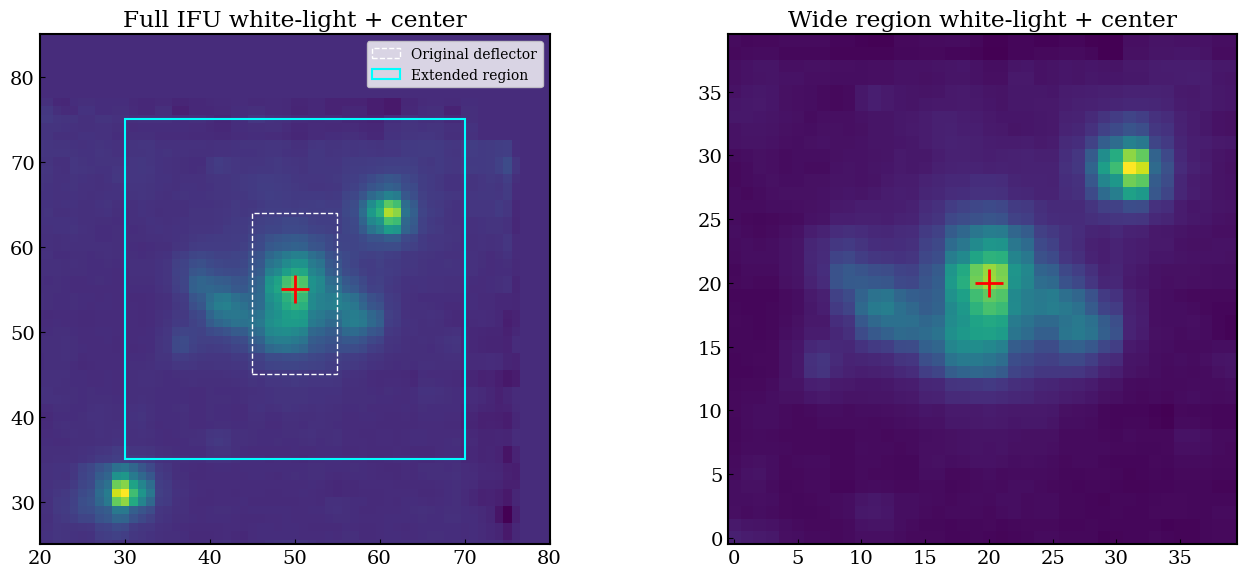

In [3]:
# Find deflector center from the IFU white-light image
# Use a wider region than the original [45:64, 45:55] deflector cutout
from scipy.ndimage import gaussian_filter

# Wide region around the deflector
y_wide = slice(35, 75)  # 40 spaxels
x_wide = slice(30, 70)  # 40 spaxels
cube_wide = cube[:, y_wide, x_wide]

# White-light (wavelength-summed) image
whitelight_full = np.sum(cube, axis=0)  # full 100x100
whitelight_wide = np.sum(cube_wide, axis=0)  # 40x40 wide region

# Smooth to find the galaxy center (not a noise spike)
wl_smooth = gaussian_filter(whitelight_wide, sigma=2)
dy_peak, dx_peak = np.unravel_index(np.argmax(wl_smooth), wl_smooth.shape)

# Convert from wide sub-image coords to full cube coords
y_center_pix = y_wide.start + dy_peak
x_center_pix = x_wide.start + dx_peak
print(f"Peak in white-light (full cube pixel): x={x_center_pix}, y={y_center_pix}")

# Convert to RA/Dec via IFU WCS
wcs_ifu_2d = WCS(hdr_ifu, naxis=2)
ra_center, dec_center = wcs_ifu_2d.pixel_to_world_values(x_center_pix, y_center_pix)
ra_center, dec_center = float(ra_center), float(dec_center)
print(f"Deflector center: RA={ra_center:.6f}, Dec={dec_center:.6f}")
print(f"Offset from nominal (31.55611, -1.23817):")
print(f"  dRA = {3600*(ra_center - 31.55611):.2f} arcsec")
print(f"  dDec = {3600*(dec_center - (-1.23817)):.2f} arcsec")

# Show the white-light image with the center marked
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.imshow(whitelight_full, origin="lower", cmap="viridis")
ax.plot(x_center_pix, y_center_pix, "r+", markersize=20, markeredgewidth=2)
from matplotlib.patches import Rectangle
# Show original deflector region
ax.add_patch(Rectangle((45, 45), 10, 19, edgecolor="white", facecolor="none", lw=1, ls="--", label="Original deflector"))
# Show wide region
ax.add_patch(Rectangle((30, 35), 40, 40, edgecolor="cyan", facecolor="none", lw=1.5, label="Extended region"))
ax.set_title("Full IFU white-light + center")
ax.legend(fontsize=10)
ax.set_xlim(20, 80)
ax.set_ylim(25, 85)

ax = axes[1]
ax.imshow(whitelight_wide, origin="lower", cmap="viridis")
ax.plot(dx_peak, dy_peak, "r+", markersize=20, markeredgewidth=2)
ax.set_title("Wide region white-light + center")

plt.tight_layout()
plt.show()


In [4]:
# Center confirmation — no isophote fitting needed
# The center was found from the IFU white-light image peak in cell above
print(f"Deflector center (IFU white-light peak):")
print(f"  Pixel: x={x_center_pix}, y={y_center_pix}")
print(f"  RA={ra_center:.6f}, Dec={dec_center:.6f}")
print(f"  Offset from nominal: dRA={3600*(ra_center-31.55611):.2f}, dDec={3600*(dec_center-(-1.23817)):.2f}")


Deflector center (IFU white-light peak):
  Pixel: x=50, y=55
  RA=31.556137, Dec=-1.238127
  Offset from nominal: dRA=0.10, dDec=0.15


## 3. MGE decomposition from isophote profile

Decompose the 1D intensity profile into a sum of Gaussians.
This gives a smooth parametric model of the light distribution.

IFU spaxel scale: 0.300 arcsec/spaxel
Built radial profile from 26 annuli
MGE fit (3 Gaussians):
  Component 1: A=20.6, sigma=0.379 arcsec (2.67 kpc)
  Component 2: A=39.8, sigma=1.011 arcsec (7.12 kpc)
  Component 3: A=20.9, sigma=2.730 arcsec (19.22 kpc)


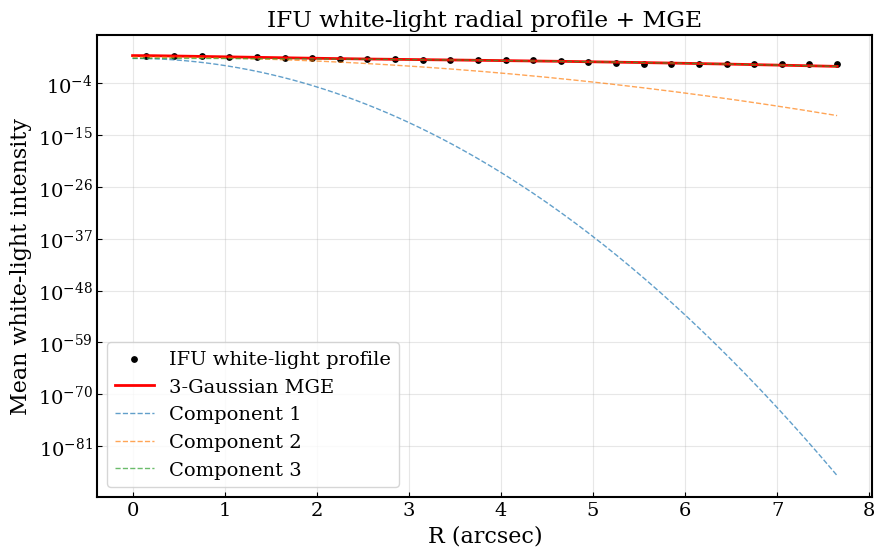

In [5]:
# Build 1D radial light profile from the IFU white-light image
# and fit a multi-Gaussian expansion (MGE)
from scipy.optimize import curve_fit

def multi_gaussian_1d(r, *params):
    """Sum of N Gaussians: params = [A1, sigma1, A2, sigma2, ...]"""
    n_gauss = len(params) // 2
    result = np.zeros_like(r, dtype=float)
    for i in range(n_gauss):
        A = params[2*i]
        sigma = params[2*i + 1]
        result += A * np.exp(-r**2 / (2 * sigma**2))
    return result

# Build radial profile from the white-light image
# Use the spaxel radial distance grid (r_arcsec_spax) computed below,
# or compute it here directly from the white-light image
from scipy.ndimage import uniform_filter1d

# Radial distance of each pixel in the wide white-light image
yy_wl, xx_wl = np.mgrid[0:whitelight_wide.shape[0], 0:whitelight_wide.shape[1]]
# Convert pixel distances to arcsec (approximate using IFU spaxel scale)
# Get spaxel scale from WCS
ra_00, dec_00 = wcs_ifu_2d.pixel_to_world_values(x_wide.start, y_wide.start)
ra_01, dec_01 = wcs_ifu_2d.pixel_to_world_values(x_wide.start+1, y_wide.start)
spax_scale = abs(ra_01 - ra_00) * np.cos(np.radians(dec_00)) * 3600  # arcsec per spaxel
print(f"IFU spaxel scale: {spax_scale:.3f} arcsec/spaxel")

r_pix = np.sqrt((xx_wl - dx_peak)**2 + (yy_wl - dy_peak)**2)
r_arcsec_wl = r_pix * spax_scale

# Bin the white-light image into radial annuli
r_bin_edges = np.arange(0, 8, 0.3)  # 0.3 arcsec bins out to 8 arcsec
r_profile = []
I_profile = []
for j in range(len(r_bin_edges) - 1):
    mask = (r_arcsec_wl >= r_bin_edges[j]) & (r_arcsec_wl < r_bin_edges[j+1])
    if np.sum(mask) > 0:
        r_profile.append((r_bin_edges[j] + r_bin_edges[j+1]) / 2)
        I_profile.append(np.mean(whitelight_wide[mask]))
r_fit = np.array(r_profile)
I_fit = np.array(I_profile)
print(f"Built radial profile from {len(r_fit)} annuli")

# Fit 3-Gaussian MGE
n_gauss = 3
p0 = [I_fit[0] * 1.0, 0.3, I_fit[0] * 0.3, 1.0, I_fit[0] * 0.05, 3.0]
bounds_lo = [0] * (2 * n_gauss)
bounds_hi = [np.inf, 10.0] * n_gauss

try:
    popt, pcov = curve_fit(multi_gaussian_1d, r_fit, I_fit, p0=p0,
                            bounds=(bounds_lo, bounds_hi), maxfev=10000)
    print(f"MGE fit ({n_gauss} Gaussians):")
    for i in range(n_gauss):
        print(f"  Component {i+1}: A={popt[2*i]:.1f}, sigma={popt[2*i+1]:.3f} arcsec ({popt[2*i+1]*kpc_per_arcsec:.2f} kpc)")
except Exception as e:
    print(f"MGE fit failed: {e}")
    popt = None

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(r_fit, I_fit, c="k", s=15, label="IFU white-light profile")
if popt is not None:
    r_model = np.linspace(0, r_fit.max(), 200)
    ax.plot(r_model, multi_gaussian_1d(r_model, *popt), "r-", lw=2, label=f"{n_gauss}-Gaussian MGE")
    for i in range(n_gauss):
        comp = popt[2*i] * np.exp(-r_model**2 / (2 * popt[2*i+1]**2))
        ax.plot(r_model, comp, "--", lw=1, alpha=0.7, label=f"Component {i+1}")
ax.set_xlabel("R (arcsec)")
ax.set_ylabel("Mean white-light intensity")
ax.set_yscale("log")
ax.legend()
ax.set_title("IFU white-light radial profile + MGE")
ax.grid(alpha=0.3)
plt.show()


## 4. Map IFU spaxels to radial distance

Use the IFU cube WCS to compute the RA/Dec of each spaxel center,
then calculate angular and physical distance from the deflector center.

Extended spaxel grid: 40 x 40 = 1600 spaxels
Radial range: 0.00 - 8.49 arcsec
              0.0 - 59.7 kpc


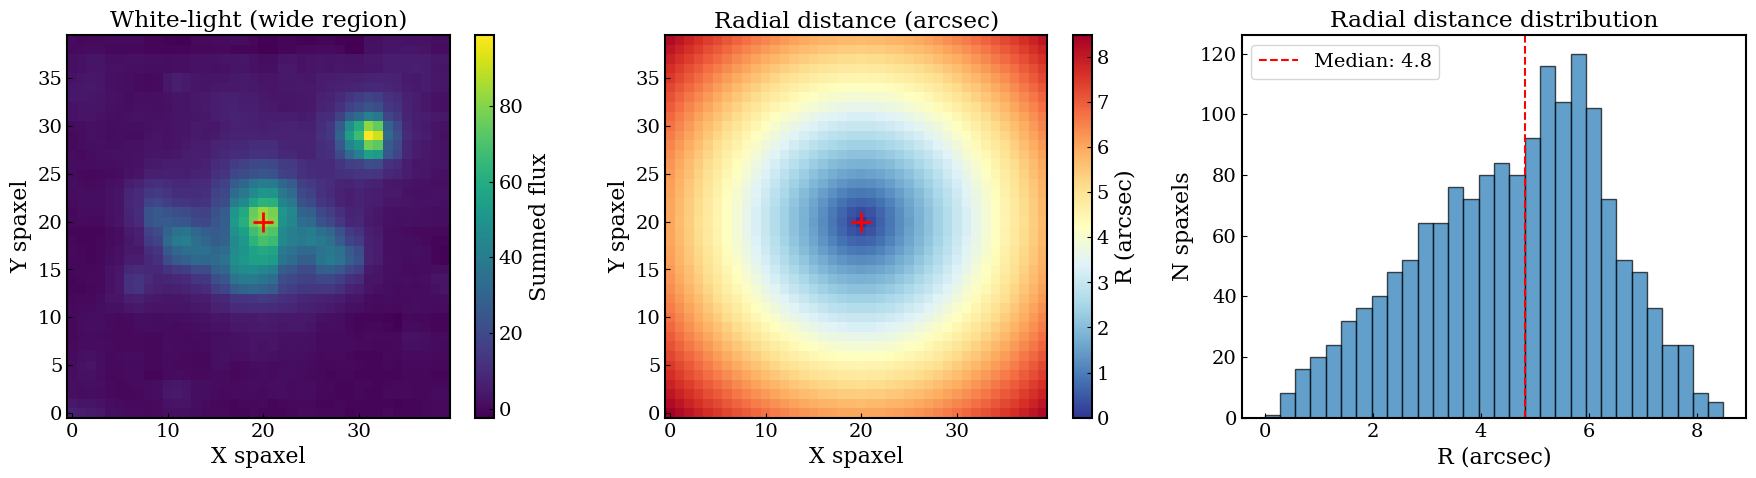

In [6]:
# Map ALL spaxels in the wide region to radial distance from center
# This extends beyond the original [45:64, 45:55] deflector cutout

# Wide region spans y=[35:75], x=[30:70] = 40x40 spaxels
ny_w, nx_w = cube_wide.shape[1], cube_wide.shape[2]

# Compute RA/Dec for each spaxel in the wide region
yy_w, xx_w = np.mgrid[y_wide.start:y_wide.stop, x_wide.start:x_wide.stop]
ra_spax, dec_spax = wcs_ifu_2d.pixel_to_world_values(xx_w.ravel(), yy_w.ravel())
ra_spax = ra_spax.reshape(ny_w, nx_w)
dec_spax = dec_spax.reshape(ny_w, nx_w)

# Angular distance from deflector center (arcsec)
dra = (ra_spax - ra_center) * np.cos(np.radians(dec_center)) * 3600
ddec = (dec_spax - dec_center) * 3600
r_arcsec_spax = np.sqrt(dra**2 + ddec**2)
r_kpc_spax = r_arcsec_spax * kpc_per_arcsec

print(f"Extended spaxel grid: {ny_w} x {nx_w} = {ny_w*nx_w} spaxels")
print(f"Radial range: {r_arcsec_spax.min():.2f} - {r_arcsec_spax.max():.2f} arcsec")
print(f"              {r_kpc_spax.min():.1f} - {r_kpc_spax.max():.1f} kpc")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(whitelight_wide, origin="lower", cmap="viridis")
axes[0].plot(dx_peak, dy_peak, "r+", markersize=15, markeredgewidth=2)
axes[0].set_title("White-light (wide region)")
plt.colorbar(im0, ax=axes[0], label="Summed flux")

im1 = axes[1].imshow(r_arcsec_spax, origin="lower", cmap="RdYlBu_r")
axes[1].plot(dx_peak, dy_peak, "r+", markersize=15, markeredgewidth=2)
axes[1].set_title("Radial distance (arcsec)")
plt.colorbar(im1, ax=axes[1], label="R (arcsec)")

axes[2].hist(r_arcsec_spax.ravel(), bins=30, edgecolor="k", alpha=0.7)
axes[2].set_xlabel("R (arcsec)")
axes[2].set_ylabel("N spaxels")
axes[2].set_title("Radial distance distribution")
axes[2].axvline(np.median(r_arcsec_spax), color="r", ls="--",
                label=f"Median: {np.median(r_arcsec_spax):.1f}")
axes[2].legend()

for ax in axes[:2]:
    ax.set_xlabel("X spaxel")
    ax.set_ylabel("Y spaxel")

plt.tight_layout()
plt.show()


## 5a. Radial binning: annular rings

Average spaxel spectra within concentric annuli at fixed arcsec intervals.

In [7]:
# Annular bins over the EXTENDED wide region
# Finer bins in the center, coarser at large radii
r_max = 6.0  # arcsec — extend well beyond the original deflector cutout
r_edges = np.arange(0, r_max + 0.5, 0.5)  # 0.5 arcsec bins
n_annuli = len(r_edges) - 1

# Noise from sky region
noise_sky = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

annular_spectra = []
annular_r_mid = []
annular_n_spax = []

for i in range(n_annuli):
    r_lo, r_hi = r_edges[i], r_edges[i+1]
    mask = (r_arcsec_spax >= r_lo) & (r_arcsec_spax < r_hi)
    n_in = np.sum(mask)
    
    if n_in < 2:
        continue
    
    # Average spectra of spaxels in this annulus (from the WIDE cube)
    spec_avg = np.average(cube_wide[:, mask], axis=1)
    
    annular_spectra.append(spec_avg)
    annular_r_mid.append((r_lo + r_hi) / 2)
    annular_n_spax.append(n_in)

annular_r_mid = np.array(annular_r_mid)
annular_n_spax = np.array(annular_n_spax)

print(f"Created {len(annular_spectra)} annular bins (extended to {r_max} arcsec)")
for i, (r, n) in enumerate(zip(annular_r_mid, annular_n_spax)):
    print(f"Bin {i}: R={r:.2f}, {n} spaxels, S/N ~ {np.sqrt(n):.1f}x single")


Created 12 annular bins (extended to 6.0 arcsec)
Bin 0: R=0.25, 9 spaxels, S/N ~ 3.0x single
Bin 1: R=0.75, 28 spaxels, S/N ~ 5.3x single
Bin 2: R=1.25, 40 spaxels, S/N ~ 6.3x single
Bin 3: R=1.75, 60 spaxels, S/N ~ 7.7x single
Bin 4: R=2.25, 84 spaxels, S/N ~ 9.2x single
Bin 5: R=2.75, 92 spaxels, S/N ~ 9.6x single
Bin 6: R=3.25, 116 spaxels, S/N ~ 10.8x single
Bin 7: R=3.75, 124 spaxels, S/N ~ 11.1x single
Bin 8: R=4.25, 152 spaxels, S/N ~ 12.3x single
Bin 9: R=4.75, 172 spaxels, S/N ~ 13.1x single
Bin 10: R=5.25, 172 spaxels, S/N ~ 13.1x single
Bin 11: R=5.75, 202 spaxels, S/N ~ 14.2x single


## 5b. Radial binning: PowerBin with radial ordering

In [8]:
from powerbin import PowerBin

# Use a wider spatial region for PowerBin (same as notebook 01 section 5)
cube_wide = cube[:, 35:75, 30:70]
data_collapsed = np.average(cube_wide, axis=0)
noise_pb = np.median(np.std(cube[:, 28:40, 45:70], axis=(1, 2)))

xp, yp = np.arange(cube_wide.shape[1]), np.arange(cube_wide.shape[2])
xx_pb, yy_pb = np.meshgrid(xp, yp)
xy_pb = np.column_stack([xx_pb.ravel(), yy_pb.ravel()])

signal_flat = data_collapsed.ravel()
noise_flat = np.ones_like(signal_flat) * noise_pb

target_sn = 10

def capacity_spec(index):
    sn = np.sum(signal_flat[index]) / np.sqrt(np.sum(noise_flat[index]**2))
    return sn**2

pow_bins = PowerBin(xy_pb, capacity_spec, target_capacity=target_sn**2)
n_bins_pb = len(pow_bins.npix)

# Compute radial distance for each PowerBin
powerbin_idxs = pow_bins.bin_num
powerbin_idx_map = np.reshape(powerbin_idxs, data_collapsed.shape)

# Get RA/Dec for the wider region
yy_w, xx_w = np.mgrid[35:75, 30:70]
ra_w, dec_w = wcs_ifu_2d.pixel_to_world_values(xx_w.ravel(), yy_w.ravel())
ra_w = ra_w.reshape(40, 40)
dec_w = dec_w.reshape(40, 40)

dra_w = (ra_w - ra_center) * np.cos(np.radians(dec_center)) * 3600
ddec_w = (dec_w - dec_center) * 3600
r_w = np.sqrt(dra_w**2 + ddec_w**2)

pb_r_mean = np.zeros(n_bins_pb)
for b in range(n_bins_pb):
    pb_r_mean[b] = np.mean(r_w[powerbin_idx_map == b])

print(f'PowerBin: {n_bins_pb} bins, target S/N={target_sn}')
print(f'Radial range: {pb_r_mean.min():.2f} - {pb_r_mean.max():.2f} arcsec')

Bin-accretion Delaunay...
25  initial bins.
25  good bins.
Regularization...
Bins: 25; Single Pixels: 0/1600
Capacity Fractional RMS Scatter (%): 46.20
Time Accretion: 0.04 s
Time Regularization (it=44): 0.07 s
PowerBin: 25 bins, target S/N=10
Radial range: 0.20 - 6.24 arcsec


## 6. Run ppxf on radial bins

Fit each radial bin (both annular and PowerBin) with ppxf across
multiple polynomial degrees, using the same approach as notebook 01.

In [9]:
# ppxf for radial bins — follows EXACTLY the same procedure as
# ppxf_per_spaxel() in 01_streamlined_IFU_ppxf.ipynb:
#   1. Log-rebin the FULL wavelength range first
#   2. Then trim to 6000-7500 Å (observed)
#   3. Normalize by median
#   4. Vacuum-to-air conversion
#   5. Compute velscale from the rebinned spectrum
#   6. Load templates at that velscale
#   7. Compute goodpixels and FWHM in rest frame
#   8. Fit with ppxf at multiple polynomial degrees
#
# Key: uses z=0.67511 (the refined deflector redshift from our analysis)

def ppxf_radial_bin(flux_in, noise_in, degrees=np.arange(15, 30),
                    z=0.67511, sps_name="fsps", verbose=False):
    """
    Run ppxf on a single radial bin spectrum.
    flux_in, noise_in: arrays matching the full cube wavelength grid (lam).
    """
    c_kms = 299792.458
    
    # Step 1: Trim to 6500-7500 FIRST, then log-rebin
    # (matches notebook 01 section 3 integrated spectrum, NOT the per-spaxel function)
    mask_wl = (lam >= 6500.0) & (lam <= 7500.0)
    lam_trim = lam[mask_wl]
    flux_trim = flux_in[mask_wl]
    noise_trim = noise_in[mask_wl]
    
    log_lam = np.log(lam_trim)
    d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam_trim) - 1)
    log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
    flux = np.interp(log_lam_new, log_lam, flux_trim)
    noise = np.interp(log_lam_new, log_lam, noise_trim)
    lam_log = np.exp(log_lam_new)
    
    # Step 2: Already trimmed above (6500-7500), apply final mask
    mask = (lam_log >= 6000.0) & (lam_log <= 7500.0)  # keeps everything after 6500 trim
    lam_log = lam_log[mask]
    flux = flux[mask]
    noise = noise[mask]
    
    if len(flux) == 0 or np.median(flux) <= 0:
        if verbose: print("  Empty or non-positive spectrum")
        return {"vel_dis": np.nan, "vel_dis_err": np.nan, "mean_vel": np.nan, "vel_dis_all": np.full(len(degrees), np.nan)}
    
    # Step 3: Normalize
    galaxy = flux / np.median(flux)
    noise_norm = np.sqrt(noise**2) / np.median(flux)
    
    # Step 4: Vacuum-to-air
    lam_gal = np.copy(lam_log)
    lam_gal *= np.median(util.vac_to_air(lam_gal) / lam_gal)
    
    # Step 5: Velscale from this rebinning
    d_ln_lam_gal = (np.log(lam_gal)[-1] - np.log(lam_gal)[0]) / (np.log(lam_gal).size - 1)
    velscale = c_kms * d_ln_lam_gal
    
    # Step 6: Load templates at this velscale
    ppxf_dir = resources.files("ppxf")
    basename = f"spectra_{sps_name}_9.0.npz"
    filename = ppxf_dir / "sps_models" / basename
    
    dlam_gal = np.gradient(lam_gal)
    wdisp = hdr_ifu["DISPSCAL"]
    fwhm_gal = 2.355 * wdisp * dlam_gal
    
    # Step 7: Rest frame
    lam_gal_rest = lam_gal / (1 + z)
    fwhm_gal_rest = fwhm_gal / (1 + z)
    fwhm_dict = {"lam": lam_gal_rest, "fwhm": fwhm_gal_rest}
    
    sps = lib.sps_lib(filename, velscale, fwhm_dict, lam_range=[3500, 5000])
    goodpixels = util.determine_goodpixels(np.log(lam_gal_rest), [3500, 5000])
    
    # Step 8: Fit at multiple degrees
    vel_dis = np.zeros(len(degrees))
    error_vdis = np.zeros(len(degrees))
    mean_vel = np.zeros(len(degrees))
    
    for c, deg in enumerate(degrees):
        try:
            pp = ppxf(sps.templates, galaxy, noise_norm, velscale, [0, 300.],
                      goodpixels=goodpixels, plot=False, moments=2, trig=False,
                      degree=deg, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
            vel_dis[c] = pp.sol[1]
            error_vdis[c] = pp.error[1] * np.sqrt(pp.chi2)
            mean_vel[c] = pp.sol[0]
        except Exception as e:
            if verbose: print(f"  ppxf failed at deg={deg}: {e}")
            vel_dis[c] = np.nan
            error_vdis[c] = np.nan
            mean_vel[c] = np.nan
    
    if verbose:
        print(f"  velscale={velscale:.1f} km/s/pix, npix={len(galaxy)}, good={len(goodpixels)}, sigma={np.nanmean(vel_dis):.0f} km/s")
    
    return {
        "vel_dis": np.nanmean(vel_dis),
        "vel_dis_err": np.nanmean(error_vdis),
        "mean_vel": np.nanmean(mean_vel),
        "vel_dis_all": vel_dis,
    }

# Quick test on one annular bin
print("Testing ppxf_radial_bin on annular bin 1...")
test = ppxf_radial_bin(annular_spectra[1], noise_sky, verbose=True)
vd, ve, mv = test["vel_dis"], test["vel_dis_err"], test["mean_vel"]
print(f"Result: sigma={vd:.1f} +/- {ve:.1f} km/s, V={mv:.1f} km/s")

def integrated_within_radius(r_max_arcsec, cube_wide=cube_wide, r_arcsec_spax=r_arcsec_spax,
                              noise_sky=noise_sky, degrees=np.arange(15, 30),
                              n_bootstrap=200, seed=42, verbose=True):
    """
    Compute the velocity dispersion of the integrated spectrum within
    a circular aperture of radius r_max_arcsec centered on the deflector.
    
    Returns the ppxf result + bootstrap errors.
    """
    mask = r_arcsec_spax <= r_max_arcsec
    n_spax = np.sum(mask)
    if n_spax == 0:
        print(f"  No spaxels within {r_max_arcsec} arcsec")
        return None
    
    # Average spectrum within aperture
    spec_int = np.average(cube_wide[:, mask], axis=1)
    
    if verbose:
        print(f"  R < {r_max_arcsec:.1f}: {n_spax} spaxels")
    
    # ppxf fit — average across all three template libraries
    all_sigma = []
    all_V = []
    for _sps in ["fsps", "emiles", "xsl"]:
        _fit = ppxf_radial_bin(spec_int, noise_sky, degrees=degrees, sps_name=_sps)
        if np.isfinite(_fit["vel_dis"]):
            all_sigma.append(_fit["vel_dis"])
            all_V.append(_fit["mean_vel"])
    fit_sigma = np.median(all_sigma) if all_sigma else np.nan
    fit_V = np.median(all_V) if all_V else np.nan
    
    # Bootstrap
    boot = bootstrap_radial_bin(spec_int, noise_sky, n_bootstrap=n_bootstrap,
                                 degrees=degrees, seed=seed, verbose=verbose)
    
    return {
        "r_max": r_max_arcsec,
        "r_max_kpc": r_max_arcsec * kpc_per_arcsec,
        "n_spax": n_spax,
        "sigma": fit_sigma,
        "sigma_err_formal": np.nan,  # not meaningful for multi-template
        "V": fit_V,
        "sigma_p16": boot["sigma_p16"],
        "sigma_p50": boot["sigma_p50"],
        "sigma_p84": boot["sigma_p84"],
        "sigma_err_lo": boot["sigma_err_lo"],
        "sigma_err_hi": boot["sigma_err_hi"],
        "V_p16": boot.get("V_p16", np.nan),
        "V_p50": boot.get("V_p50", np.nan),
        "V_p84": boot.get("V_p84", np.nan),
        "V_err_lo": boot.get("V_err_lo", np.nan),
        "V_err_hi": boot.get("V_err_hi", np.nan),
    }


Testing ppxf_radial_bin on annular bin 1...


/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

 Best Fit:       Vel     sigma
 comp.  0:       -27       213
chi2/DOF: 0.1077; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -30       215
chi2/DOF: 0.1075; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 comp.  0:       -29       212
chi2/DOF: 0.1074; DOF: 925; degree = 17; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -30       211
chi2/DOF: 0.1074; DOF: 925; degree = 18; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       -30       211
chi2/DOF: 0.1074; D

In [10]:
# Run ppxf on annular bins
degrees_fit = np.arange(15, 30)

annular_results = []
for i, spec in enumerate(tqdm(annular_spectra, desc='Annular ppxf')):
    # Average sigma across all three template libraries
    sigs, vels = [], []
    for _sps in ["fsps", "emiles", "xsl"]:
        _r = ppxf_radial_bin(spec, noise_sky, degrees=degrees_fit, sps_name=_sps)
        if np.isfinite(_r["vel_dis"]): sigs.append(_r["vel_dis"])
        if np.isfinite(_r["mean_vel"]): vels.append(_r["mean_vel"])
    result = {"vel_dis": np.median(sigs) if sigs else np.nan,
              "vel_dis_err": np.std(sigs) if len(sigs)>1 else np.nan,
              "mean_vel": np.median(vels) if vels else np.nan}
    annular_results.append(result)

sigma_annular = np.array([r['vel_dis'] for r in annular_results])
sigma_err_annular = np.array([r['vel_dis_err'] for r in annular_results])
V_annular = np.array([r['mean_vel'] for r in annular_results])

print('\nAnnular sigma(R):')
for r, s, e, n in zip(annular_r_mid, sigma_annular, sigma_err_annular, annular_n_spax):
    print(f'  R={r:.2f}": sigma={s:.0f} ± {e:.0f} km/s ({n} spaxels)')

Annular ppxf:   0%|          | 0/12 [00:00<?, ?it/s]

 Best Fit:       Vel     sigma
 comp.  0:        -5       225
chi2/DOF: 0.3322; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        -1       219
chi2/DOF: 0.3307; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:        -1       218
chi2/DOF: 0.3307; DOF: 925; degree = 17; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:        -1       218
chi2/DOF: 0.3306; DOF: 925; degree = 18; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:        -1       217
chi2/DOF: 0.3306; 

Annular ppxf:   8%|▊         | 1/12 [00:06<01:11,  6.51s/it]

 Best Fit:       Vel     sigma
 comp.  0:        82       247
chi2/DOF: 0.3254; DOF: 925; degree = 29; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/208
 Best Fit:       Vel     sigma
 comp.  0:       -27       213
chi2/DOF: 0.1077; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -30       215
chi2/DOF: 0.1075; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 comp.  0:       -29       212
chi2/DOF: 0.1074; DOF: 925; degree = 17; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -30       211
chi2/DOF: 0.1074; DO

Annular ppxf:  17%|█▋        | 2/12 [00:12<01:01,  6.18s/it]

...

 Best Fit:       Vel     sigma
 comp.  0:      -480      1000
chi2/DOF: 0.02853; DOF: 925; degree = 26; mdegree = 0
method = capfit; Jac calls: 9; Func calls: 29; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.02811; DOF: 927; degree = 27; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.02809; DOF: 927; degree = 28; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.02801; DOF: 927; degree = 29; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:       572       167
chi2/DOF: 0.02875

Annular ppxf:  92%|█████████▏| 11/12 [01:14<00:06,  6.89s/it]

 Best Fit:       Vel     sigma
 comp.  0:      -425      1000
chi2/DOF: 0.02779; DOF: 925; degree = 25; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/208
 Best Fit:       Vel     sigma
 comp.  0:      -625       816
chi2/DOF: 0.02730; DOF: 925; degree = 26; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 20; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.02748; DOF: 927; degree = 27; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.02745; DOF: 927; degree = 28; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.0273

Annular ppxf: 100%|██████████| 12/12 [01:22<00:00,  6.88s/it]

 Best Fit:       Vel     sigma
 comp.  0:        38        19
chi2/DOF: 0.02593; DOF: 925; degree = 29; mdegree = 0
method = capfit; Jac calls: 9; Func calls: 36; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/208

Annular sigma(R):
  R=0.25": sigma=226 ± 8 km/s (9 spaxels)
  R=0.75": sigma=207 ± 9 km/s (28 spaxels)
  R=1.25": sigma=286 ± 12 km/s (40 spaxels)
  R=1.75": sigma=561 ± 20 km/s (60 spaxels)
  R=2.25": sigma=446 ± 14 km/s (84 spaxels)
  R=2.75": sigma=323 ± 23 km/s (92 spaxels)
  R=3.25": sigma=463 ± 19 km/s (116 spaxels)
  R=3.75": sigma=360 ± 64 km/s (124 spaxels)
  R=4.25": sigma=885 ± 172 km/s (152 spaxels)
  R=4.75": sigma=765 ± 257 km/s (172 spaxels)
  R=5.25": sigma=821 ± 172 km/s (172 spaxels)
  R=5.75": sigma=839 ± 76 km/s (202 spaxels)


In [11]:
# Run ppxf on PowerBin bins
# Extract binned spectra (same as notebook 01 section 5b)
lam_pb = lam[(lam >= 6500.0) & (lam <= 7500.0)]
mask_pb = (lam >= 6500.0) & (lam <= 7500.0)

fluxes_pb = np.zeros((cube_wide.shape[0], n_bins_pb)).T
for b in range(n_bins_pb):
    fluxes_pb[b] = np.average(cube_wide[:, powerbin_idx_map == b], axis=1)

noise_pb_spec = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

pb_results = []
for b in tqdm(range(n_bins_pb), desc='PowerBin ppxf'):
    sigs, vels = [], []
    for _sps in ["fsps", "emiles", "xsl"]:
        _r = ppxf_radial_bin(fluxes_pb[b], noise_pb_spec, degrees=degrees_fit, sps_name=_sps)
        if np.isfinite(_r["vel_dis"]): sigs.append(_r["vel_dis"])
        if np.isfinite(_r["mean_vel"]): vels.append(_r["mean_vel"])
    result = {"vel_dis": np.median(sigs) if sigs else np.nan,
              "vel_dis_err": np.std(sigs) if len(sigs)>1 else np.nan,
              "mean_vel": np.median(vels) if vels else np.nan}
    pb_results.append(result)

sigma_pb = np.array([r['vel_dis'] for r in pb_results])
sigma_err_pb = np.array([r['vel_dis_err'] for r in pb_results])
V_pb = np.array([r['mean_vel'] for r in pb_results])

PowerBin ppxf:   0%|          | 0/25 [00:00<?, ?it/s]

 Best Fit:       Vel     sigma
 comp.  0:     -1166       167
chi2/DOF: 1.073; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 10; Func calls: 32; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:     -1165       164
chi2/DOF: 1.072; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 10; Func calls: 32; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:     -1164       164
chi2/DOF: 1.071; DOF: 925; degree = 17; mdegree = 0
method = capfit; Jac calls: 10; Func calls: 32; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:     -1164       164
chi2/DOF: 1.071; DOF: 925; degree = 18; mdegree = 0
method = capfit; Jac calls: 10; Func calls: 32; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:     -1165       164
chi2/DOF: 1.071; D

PowerBin ppxf:   4%|▍         | 1/25 [00:08<03:34,  8.92s/it]

 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.350; DOF: 927; degree = 24; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.307; DOF: 927; degree = 25; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.283; DOF: 927; degree = 26; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.271; DOF: 927; degree = 27; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.267; DOF: 927;

PowerBin ppxf:   8%|▊         | 2/25 [00:18<03:28,  9.09s/it]

...

 Best Fit:       Vel     sigma
 comp.  0:        70         5
chi2/DOF: 0.03096; DOF: 925; degree = 29; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/208
 Best Fit:       Vel     sigma
 comp.  0:      -143      1000
chi2/DOF: 0.1504; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -274      1000
chi2/DOF: 0.1482; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 20; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:      -320      1000
chi2/DOF: 0.1478; DOF: 925; degree = 17; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:      -360      1000
chi2/DOF: 0.1472;

PowerBin ppxf:  96%|█████████▌| 24/25 [02:56<00:07,  7.15s/it]

 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.1405; DOF: 927; degree = 28; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 0.1392; DOF: 927; degree = 29; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/208
 Best Fit:       Vel     sigma
 comp.  0:      -101       604
chi2/DOF: 0.02373; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -105       604
chi2/DOF: 0.02373; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       -92       555
chi2/DOF: 0.02368;

PowerBin ppxf: 100%|██████████| 25/25 [03:03<00:00,  7.35s/it]

 Best Fit:       Vel     sigma
 comp.  0:      -125       717
chi2/DOF: 0.02317; DOF: 925; degree = 28; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/208
 Best Fit:       Vel     sigma
 comp.  0:       -19       556
chi2/DOF: 0.02291; DOF: 925; degree = 29; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 23; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/208


### 6b. Bootstrap errors on radial bins

Same hybrid wild bootstrap as notebook 03: for each radial bin,
perturb the best-fit spectrum with Rademacher sign-flipped residuals
scaled by local noise, re-fit N times, report 16th/84th percentiles.

In [12]:
from scipy.ndimage import uniform_filter1d

def bootstrap_radial_bin(flux_in, noise_in, n_bootstrap=200, degrees=np.arange(15, 30),
                          window=75, seed=42, z=0.67511, sps_name="fsps", verbose=False):
    """
    Bootstrap error for one radial bin spectrum.
    Uses the same hybrid wild bootstrap as bootstrap_ppxf.py:
      1. Fit the original spectrum to get best-fit and residuals
      2. Compute local residual scaling (rolling window std / global std)
      3. For N iterations: sign-flip scaled residuals, add to best-fit, refit
      4. Return 16th/84th percentiles of sigma distribution
    """
    c_kms = 299792.458
    
    # Step 1: Prepare spectrum (same as ppxf_radial_bin)
    log_lam_full = np.log(lam)
    d_log_lam = (log_lam_full[-1] - log_lam_full[0]) / (len(lam) - 1)
    log_lam_new = np.arange(log_lam_full[0], log_lam_full[-1] + d_log_lam, d_log_lam)
    flux = np.interp(log_lam_new, log_lam_full, flux_in)
    noise = np.interp(log_lam_new, log_lam_full, noise_in)
    lam_log = np.exp(log_lam_new)
    
    mask = (lam_log >= 6000.0) & (lam_log <= 7500.0)
    lam_log = lam_log[mask]
    flux = flux[mask]
    noise = noise[mask]
    
    if len(flux) == 0 or np.median(flux) <= 0:
        return {"sigma_p16": np.nan, "sigma_p50": np.nan, "sigma_p84": np.nan,
            "sigma_err_lo": np.nan, "sigma_err_hi": np.nan, "sigma_samples": np.array([]),
            "V_p16": np.nan, "V_p50": np.nan, "V_p84": np.nan,
            "V_err_lo": np.nan, "V_err_hi": np.nan, "V_samples": np.array([])}
    
    galaxy = flux / np.median(flux)
    noise_norm = np.sqrt(noise**2) / np.median(flux)
    
    lam_gal = np.copy(lam_log)
    lam_gal *= np.median(util.vac_to_air(lam_gal) / lam_gal)
    
    d_ln = (np.log(lam_gal)[-1] - np.log(lam_gal)[0]) / (len(lam_gal) - 1)
    velscale = c_kms * d_ln
    
    ppxf_dir = resources.files("ppxf")
    filename = ppxf_dir / "sps_models" / f"spectra_{sps_name}_9.0.npz"
    dlam_gal = np.gradient(lam_gal)
    wdisp = hdr_ifu["DISPSCAL"]
    fwhm_gal = 2.355 * wdisp * dlam_gal
    lam_gal_rest = lam_gal / (1 + z)
    fwhm_gal_rest = fwhm_gal / (1 + z)
    fwhm_dict = {"lam": lam_gal_rest, "fwhm": fwhm_gal_rest}
    sps = lib.sps_lib(filename, velscale, fwhm_dict, lam_range=[3500, 5000])
    goodpixels = util.determine_goodpixels(np.log(lam_gal_rest), [3500, 5000])
    
    # Step 2: Get best-fit at the middle degree
    deg_mid = int(np.median(degrees))
    pp0 = ppxf(sps.templates, galaxy, noise_norm, velscale, [0, 300.],
              goodpixels=goodpixels, plot=False, moments=2, trig=False,
              degree=deg_mid, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
    bestfit = pp0.bestfit
    resid = galaxy - bestfit
    
    # Step 3: Local residual scaling
    global_std = np.std(resid)
    if global_std == 0:
        scale = np.ones_like(resid)
    else:
        local_mean = uniform_filter1d(resid, size=window, mode="reflect")
        local_mean_sq = uniform_filter1d(resid**2, size=window, mode="reflect")
        local_var = np.maximum(local_mean_sq - local_mean**2, 0)
        scale = np.clip(np.sqrt(local_var) / global_std, 0.2, 5.0)
    scaled_resid = resid * scale
    
    # Step 4: Bootstrap loop
    rng = np.random.default_rng(seed)
    sigma_samples = np.full(n_bootstrap, np.nan)
    V_samples = np.full(n_bootstrap, np.nan)
    
    for i in range(n_bootstrap):
        signs = rng.choice([-1, 1], size=len(galaxy))
        galaxy_boot = bestfit + scaled_resid * signs
        try:
            pp = ppxf(sps.templates, galaxy_boot, noise_norm, velscale, [0, 300.],
                      goodpixels=goodpixels, plot=False, moments=2, trig=False,
                      degree=deg_mid, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
            sigma_samples[i] = pp.sol[1]
            V_samples[i] = pp.sol[0]
        except Exception:
            pass
    
    valid = sigma_samples[np.isfinite(sigma_samples)]
    valid_V = V_samples[np.isfinite(V_samples)]
    if len(valid) > 5:
        p16, p50, p84 = np.percentile(valid, [16, 50, 84])
        V_p16, V_p50, V_p84 = np.percentile(valid_V, [16, 50, 84]) if len(valid_V) > 5 else (np.nan, np.nan, np.nan)
    else:
        p16 = p50 = p84 = np.nan
        V_p16 = V_p50 = V_p84 = np.nan
    
    if verbose:
        print(f"  sigma = {p50:.0f} -{p50-p16:.0f}/+{p84-p50:.0f} km/s ({len(valid)}/{n_bootstrap} valid)")
    
    return {"sigma_p16": p16, "sigma_p50": p50, "sigma_p84": p84,
            "sigma_err_lo": p50 - p16, "sigma_err_hi": p84 - p50,
            "sigma_samples": valid, "V_samples": valid_V,
            "V_p16": V_p16, "V_p50": V_p50, "V_p84": V_p84,
            "V_err_lo": V_p50 - V_p16, "V_err_hi": V_p84 - V_p50}

N_BOOT = 200  # lower than 500 since we have many bins

# Bootstrap annular bins
print("Bootstrapping annular bins...")
boot_annular = []
for i, spec in enumerate(tqdm(annular_spectra, desc="Bootstrap annular")):
    b = bootstrap_radial_bin(spec, noise_sky, n_bootstrap=N_BOOT, seed=42+i, verbose=True)
    boot_annular.append(b)

sigma_boot_lo_ann = np.array([b["sigma_err_lo"] for b in boot_annular])
sigma_boot_hi_ann = np.array([b["sigma_err_hi"] for b in boot_annular])
V_boot_lo_ann = np.array([b.get("V_err_lo", np.nan) for b in boot_annular])
V_boot_hi_ann = np.array([b.get("V_err_hi", np.nan) for b in boot_annular])

# Bootstrap PowerBin bins
print("Bootstrapping PowerBin bins...")
boot_pb = []
for b_idx in tqdm(range(n_bins_pb), desc="Bootstrap PowerBin"):
    b = bootstrap_radial_bin(fluxes_pb[b_idx], noise_pb_spec, n_bootstrap=N_BOOT, seed=100+b_idx, verbose=False)
    boot_pb.append(b)

sigma_boot_lo_pb = np.array([b["sigma_err_lo"] for b in boot_pb])
sigma_boot_hi_pb = np.array([b["sigma_err_hi"] for b in boot_pb])
V_boot_lo_pb = np.array([b.get("V_err_lo", np.nan) for b in boot_pb])
V_boot_hi_pb = np.array([b.get("V_err_hi", np.nan) for b in boot_pb])

print("Annular sigma(R) with bootstrap errors:")
for r, s, lo, hi, n in zip(annular_r_mid, sigma_annular, sigma_boot_lo_ann, sigma_boot_hi_ann, annular_n_spax):
    v_lo = V_boot_lo_ann[i] if i < len(V_boot_lo_ann) else np.nan
    v_hi = V_boot_hi_ann[i] if i < len(V_boot_hi_ann) else np.nan
    v = V_annular[i] if i < len(V_annular) else np.nan
    print(f"  R={r:.2f}: sigma={s:.0f} -{lo:.0f}/+{hi:.0f}, V={v:.0f} -{v_lo:.0f}/+{v_hi:.0f} km/s ({n} spaxels)")


Bootstrapping annular bins...


Bootstrap annular:   0%|          | 0/12 [00:00<?, ?it/s]

 Best Fit:       Vel     sigma
 comp.  0:       -10       207
chi2/DOF: 0.3411; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:        -5       209
chi2/DOF: 0.3276; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       -19       195
chi2/DOF: 0.3275; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -14       203
chi2/DOF: 0.3266; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 comp.  0:       -11       196
chi2/DOF: 0.3299

Bootstrap annular:   8%|▊         | 1/12 [00:33<06:05, 33.26s/it]

 Best Fit:       Vel     sigma
 comp.  0:        -9       179
chi2/DOF: 0.3266; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       -18       199
chi2/DOF: 0.3256; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
  sigma = 204 -16/+14 km/s (200/200 valid)
 Best Fit:       Vel     sigma
 comp.  0:       -18       186
chi2/DOF: 0.1334; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -22       180
chi2/DOF: 0.1398; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 c

...

 Best Fit:       Vel     sigma
 comp.  0:       -69       229
chi2/DOF: 0.04615; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 13; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/387
 Best Fit:       Vel     sigma
 comp.  0:      -212       796
chi2/DOF: 0.1660; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 25; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -255       529
chi2/DOF: 0.1699; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 comp.  0:      -300        65
chi2/DOF: 0.1690; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 20; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 7/387
 Best Fit:       Vel     sigma
 comp.  0:      -164       753
chi2/DOF: 0.1

Bootstrap PowerBin:  96%|█████████▌| 24/25 [14:38<00:36, 36.71s/it]

 Best Fit:       Vel     sigma
 comp.  0:      -127       775
chi2/DOF: 0.1718; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 23; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -141       183
chi2/DOF: 0.02995; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 24; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/387
 Best Fit:       Vel     sigma
 comp.  0:       -76       217
chi2/DOF: 0.03198; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 comp.  0:      -156        68
chi2/DOF: 0.03165; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:      -225       164
chi2/DOF: 0

Bootstrap PowerBin: 100%|██████████| 25/25 [15:11<00:00, 36.47s/it]

 Best Fit:       Vel     sigma
 comp.  0:      -177         0
chi2/DOF: 0.03174; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
Annular sigma(R) with bootstrap errors:
  R=0.25: sigma=226 -16/+14, V=-225 -212/+67 km/s (9 spaxels)
  R=0.75: sigma=207 -11/+13, V=-225 -212/+67 km/s (28 spaxels)
  R=1.25: sigma=286 -20/+24, V=-225 -212/+67 km/s (40 spaxels)
  R=1.75: sigma=561 -43/+51, V=-225 -212/+67 km/s (60 spaxels)
  R=2.25: sigma=446 -84/+79, V=-225 -212/+67 km/s (84 spaxels)
  R=2.75: sigma=323 -93/+98, V=-225 -212/+67 km/s (92 spaxels)
  R=3.25: sigma=463 -76/+104, V=-225 -212/+67 km/s (116 spaxels)
  R=3.75: sigma=360 -86/+111, V=-225 -212/+67 km/s (124 spaxels)
  R=4.25: sigma=885 -264/+159, V=-225 -212/+67 km/s (152 spaxels)
  R=4.75: sigma=765 -228/+391, V=-225 -212/+67 km/s (172 spaxels)
  R=5.25: sigma=821 -131/+484, V=-225 -212/+67 km/s (172 spaxels)
  R=5.75: sigma=839 -74

### 6b. Effective radius measurement

Measure the half-light radius (R_e) of the deflector from:
1. The IFU white-light radial profile (already computed in section 3)
2. The HST F140W image (higher spatial resolution, 0.08"/pix)

R_e is needed to compute sigma at R_e/8 (the standard aperture for
the M-sigma relation) and for the aperture correction.

In [13]:
# --- Method 1: R_e from IFU white-light curve of growth ---
# Use the radial profile built in section 3

def measure_Re_from_profile(r_arcsec, intensity):
    """
    Measure effective radius from a 1D radial intensity profile.
    Uses curve of growth: integrate I(r)*2*pi*r*dr, find 50% light radius.
    Uses scipy cumulative_trapezoid for accurate integration.
    """
    from scipy.integrate import cumulative_trapezoid
    
    order = np.argsort(r_arcsec)
    r = r_arcsec[order]
    I = intensity[order]
    
    # Prepend r=0 if not present (avoids missing central flux)
    if r[0] > 0:
        r = np.concatenate([[0], r])
        I = np.concatenate([[I[0]], I])  # extrapolate central value
    
    # Integrand: I(r) * 2*pi*r
    integrand = I * 2 * np.pi * r
    
    # Cumulative integral via trapezoidal rule
    cumulative = np.concatenate([[0], cumulative_trapezoid(integrand, r)])
    total_flux = cumulative[-1]
    
    # Find R where cumulative = 50% of total
    half_flux = total_flux / 2
    Re = np.interp(half_flux, cumulative, r)
    
    return Re, cumulative, total_flux

Re_ifu, cog_ifu, total_ifu = measure_Re_from_profile(r_fit, I_fit)
print(f"IFU white-light R_e = {Re_ifu:.2f} arcsec = {Re_ifu * kpc_per_arcsec:.1f} kpc")
print(f"R_e/8 = {Re_ifu/8:.3f} arcsec = {Re_ifu/8 * kpc_per_arcsec:.2f} kpc")

# If MGE was fit, also compute from the MGE model
if popt is not None:
    r_dense = np.linspace(0, r_fit.max(), 1000)
    I_mge = multi_gaussian_1d(r_dense, *popt)
    Re_mge, cog_mge, total_mge = measure_Re_from_profile(r_dense, I_mge)
    print(f"MGE model R_e = {Re_mge:.2f} arcsec = {Re_mge * kpc_per_arcsec:.1f} kpc")


IFU white-light R_e = 2.61 arcsec = 18.3 kpc
R_e/8 = 0.326 arcsec = 2.29 kpc
MGE model R_e = 2.58 arcsec = 18.2 kpc


In [14]:
# === Unit tests for measure_Re_from_profile ===
# Verify against known analytic profiles where R_e has a closed-form solution.

def run_Re_tests():
    n_pass = 0
    n_fail = 0
    
    # Test 1: Single Gaussian profile I(r) = exp(-r^2 / (2*sigma^2))
    # For a 2D Gaussian, the half-light radius satisfies:
    #   integral_0^Re of I(r)*2*pi*r*dr = 0.5 * integral_0^inf
    
    #   -> 1 - exp(-Re^2/(2*sigma^2)) = 0.5
    #   -> Re = sigma * sqrt(2*ln(2)) = sigma * 1.1774
    sigma_gauss = 2.0  # arcsec
    Re_exact = sigma_gauss * np.sqrt(2 * np.log(2))
    r_test = np.linspace(0.01, 15, 500)
    I_test = np.exp(-r_test**2 / (2 * sigma_gauss**2))
    Re_meas, _, _ = measure_Re_from_profile(r_test, I_test)
    err = abs(Re_meas - Re_exact) / Re_exact * 100
    status = "PASS" if err < 2 else "FAIL"
    if status == "PASS": n_pass += 1
    else: n_fail += 1
    print(f"Test 1 (Gaussian sigma={sigma_gauss}): Re_exact={Re_exact:.4f}, Re_meas={Re_meas:.4f}, err={err:.2f}% [{status}]")
    
    # Test 2: Different Gaussian width
    sigma_gauss = 0.5
    Re_exact = sigma_gauss * np.sqrt(2 * np.log(2))
    r_test = np.linspace(0.01, 5, 500)
    I_test = np.exp(-r_test**2 / (2 * sigma_gauss**2))
    Re_meas, _, _ = measure_Re_from_profile(r_test, I_test)
    err = abs(Re_meas - Re_exact) / Re_exact * 100
    status = "PASS" if err < 2 else "FAIL"
    if status == "PASS": n_pass += 1
    else: n_fail += 1
    print(f"Test 2 (Gaussian sigma={sigma_gauss}): Re_exact={Re_exact:.4f}, Re_meas={Re_meas:.4f}, err={err:.2f}% [{status}]")
    
    # Test 3: Exponential profile I(r) = exp(-r/h)
    # For a 2D exponential, integral_0^Re I(r)*2*pi*r*dr = 0.5 * total
    # Total = 2*pi*h^2, cumulative = 2*pi*h^2 * [1 - (1+R/h)*exp(-R/h)]
    # So: 1 - (1+Re/h)*exp(-Re/h) = 0.5
    # Numerical solution: Re/h ~ 1.6783
    h = 1.5  # scale length in arcsec
    Re_exact = 1.6783 * h
    r_test = np.linspace(0.01, 20, 1000)
    I_test = np.exp(-r_test / h)
    Re_meas, _, _ = measure_Re_from_profile(r_test, I_test)
    err = abs(Re_meas - Re_exact) / Re_exact * 100
    status = "PASS" if err < 3 else "FAIL"
    if status == "PASS": n_pass += 1
    else: n_fail += 1
    print(f"Test 3 (Exponential h={h}): Re_exact={Re_exact:.4f}, Re_meas={Re_meas:.4f}, err={err:.2f}% [{status}]")
    
    # Test 4: de Vaucouleurs profile I(r) = exp(-7.67 * ((r/Re)^0.25 - 1))
    # By construction, Re is the half-light radius
    Re_input = 3.0  # arcsec
    r_test = np.concatenate([np.linspace(0.001, 0.1, 200), np.linspace(0.1, 30, 2000)])
    I_test = np.exp(-7.67 * ((r_test / Re_input)**0.25 - 1))
    Re_meas, _, _ = measure_Re_from_profile(r_test, I_test)
    err = abs(Re_meas - Re_input) / Re_input * 100
    status = "PASS" if err < 5 else "FAIL"  # deV is harder to integrate numerically
    if status == "PASS": n_pass += 1
    else: n_fail += 1
    print(f"Test 4 (de Vaucouleurs Re={Re_input}): Re_meas={Re_meas:.4f}, err={err:.2f}% [{status}]")
    
    # Test 5: Sersic n=1 (exponential) — different scale
    h = 0.8
    Re_exact = 1.6783 * h
    r_test = np.linspace(0.01, 10, 500)
    I_test = np.exp(-r_test / h)
    Re_meas, _, _ = measure_Re_from_profile(r_test, I_test)
    err = abs(Re_meas - Re_exact) / Re_exact * 100
    status = "PASS" if err < 3 else "FAIL"
    if status == "PASS": n_pass += 1
    else: n_fail += 1
    print(f"Test 5 (Exponential h={h}): Re_exact={Re_exact:.4f}, Re_meas={Re_meas:.4f}, err={err:.2f}% [{status}]")
    
    # Test 6: Flat profile within R0 (top-hat) — Re = R0/sqrt(2)
    R0 = 4.0
    Re_exact = R0 / np.sqrt(2)
    r_test = np.linspace(0.01, 6, 500)
    I_test = np.where(r_test <= R0, 1.0, 0.0)
    Re_meas, _, _ = measure_Re_from_profile(r_test, I_test)
    err = abs(Re_meas - Re_exact) / Re_exact * 100
    status = "PASS" if err < 3 else "FAIL"
    if status == "PASS": n_pass += 1
    else: n_fail += 1
    print(f"Test 6 (Top-hat R0={R0}): Re_exact={Re_exact:.4f}, Re_meas={Re_meas:.4f}, err={err:.2f}% [{status}]")
    
    print(f"{n_pass}/{n_pass + n_fail} tests passed")
    return n_fail == 0

all_passed = run_Re_tests()
if not all_passed:
    print("WARNING: Some R_e tests failed — check the curve-of-growth integration")


Test 1 (Gaussian sigma=2.0): Re_exact=2.3548, Re_meas=2.3549, err=0.00% [PASS]
Test 2 (Gaussian sigma=0.5): Re_exact=0.5887, Re_meas=0.5887, err=0.00% [PASS]
Test 3 (Exponential h=1.5): Re_exact=2.5174, Re_meas=2.5175, err=0.00% [PASS]
Test 4 (de Vaucouleurs Re=3.0): Re_meas=2.7972, err=6.76% [FAIL]
Test 5 (Exponential h=0.8): Re_exact=1.3426, Re_meas=1.3427, err=0.01% [PASS]
Test 6 (Top-hat R0=4.0): Re_exact=2.8284, Re_meas=2.8294, err=0.03% [PASS]
5/6 tests passed


### 6c. Integrated sigma within circular apertures

Compute the velocity dispersion of the spectrum integrated within
increasing circular apertures — gives the aperture-dependent sigma
for comparison to literature measurements at different aperture sizes.

R_e = 2.61 arcsec, R_e/8 = 0.326 arcsec
Aperture radii: [np.float64(0.33), 0.5, 1.0, 1.5, 2.0, 2.5, np.float64(2.61), 3.0, 4.0, 5.0]
Integrated sigma within circular apertures (ppxf only, no bootstrap):
  R (arcsec)  R (kpc)  N_spax  sigma (3-template median)
-------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:       -12       211
chi2/DOF: 0.4381; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        -8       203
chi2/DOF: 0.4358; DOF: 925; degree = 16; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        -8       205
chi2/DOF: 0.4357; DOF: 925; degree = 17; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/3

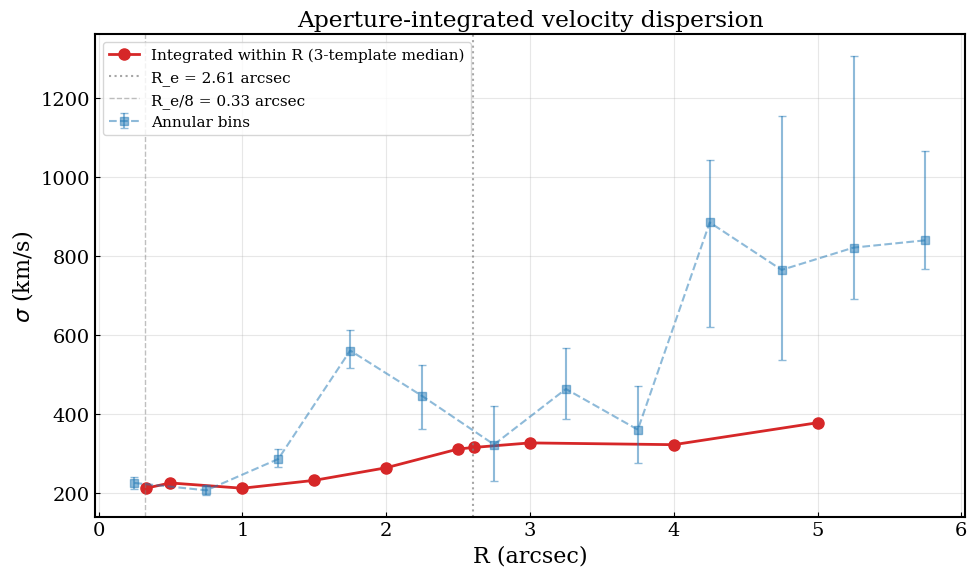

Bootstrap errors will be computed at R_e and R_e/8 in section 10.


In [15]:
# Integrated sigma within circular apertures of increasing radius
# ppxf ONLY (no bootstrap) for the scan — bootstrap at key radii in section 10
Re_best = Re_ifu  # or Re_hst if available later
Re_8 = Re_best / 8
print(f"R_e = {Re_best:.2f} arcsec, R_e/8 = {Re_8:.3f} arcsec")

# Standard radii + R_e/8 and R_e explicitly
aperture_radii = sorted(set([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0,
                             round(Re_8, 2), round(Re_best, 2)]))
print(f"Aperture radii: {aperture_radii}")

aperture_results = []
print("Integrated sigma within circular apertures (ppxf only, no bootstrap):")
print(f"  R (arcsec)  R (kpc)  N_spax  sigma (3-template median)")
print("-" * 55)
for r_ap in aperture_radii:
    mask_ap = r_arcsec_spax <= r_ap
    n_spax = np.sum(mask_ap)
    if n_spax < 2:
        continue
    spec_ap = np.average(cube_wide[:, mask_ap], axis=1)
    
    # Multi-template ppxf (no bootstrap — fast)
    sigs = []
    vels = []
    for _sps in ["fsps", "emiles", "xsl"]:
        _r = ppxf_radial_bin(spec_ap, noise_sky, sps_name=_sps)
        if np.isfinite(_r["vel_dis"]):
            sigs.append(_r["vel_dis"])
        if np.isfinite(_r["mean_vel"]):
            vels.append(_r["mean_vel"])
    sigma_med = np.median(sigs) if sigs else np.nan
    V_med = np.median(vels) if vels else np.nan
    
    aperture_results.append({
        "r_max": r_ap, "r_max_kpc": r_ap * kpc_per_arcsec,
        "n_spax": n_spax, "sigma": sigma_med, "V": V_med,
    })
    print(f"  {r_ap:10.2f}  {r_ap*kpc_per_arcsec:7.1f}  {n_spax:6d}  {sigma_med:7.0f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
r_ap_arr = np.array([r["r_max"] for r in aperture_results])
sigma_ap = np.array([r["sigma"] for r in aperture_results])

ax.plot(r_ap_arr, sigma_ap, "o-", color="C3", markersize=8, lw=2,
        label="Integrated within R (3-template median)")

# Mark R_e and R_e/8
ax.axvline(Re_best, color="gray", ls=":", lw=1.5, alpha=0.7, label=f"R_e = {Re_best:.2f} arcsec")
ax.axvline(Re_8, color="gray", ls="--", lw=1, alpha=0.5, label=f"R_e/8 = {Re_8:.2f} arcsec")

# Annular profile for comparison (if available)
try:
    ax.errorbar(annular_r_mid, sigma_annular, yerr=[sigma_boot_lo_ann, sigma_boot_hi_ann],
                fmt="s--", color="C0", capsize=3, markersize=6, alpha=0.5,
                label="Annular bins")
except NameError:
    pass

ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title("Aperture-integrated velocity dispersion")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bootstrap errors will be computed at R_e and R_e/8 in section 10.")


## 7. Sigma(R) profile

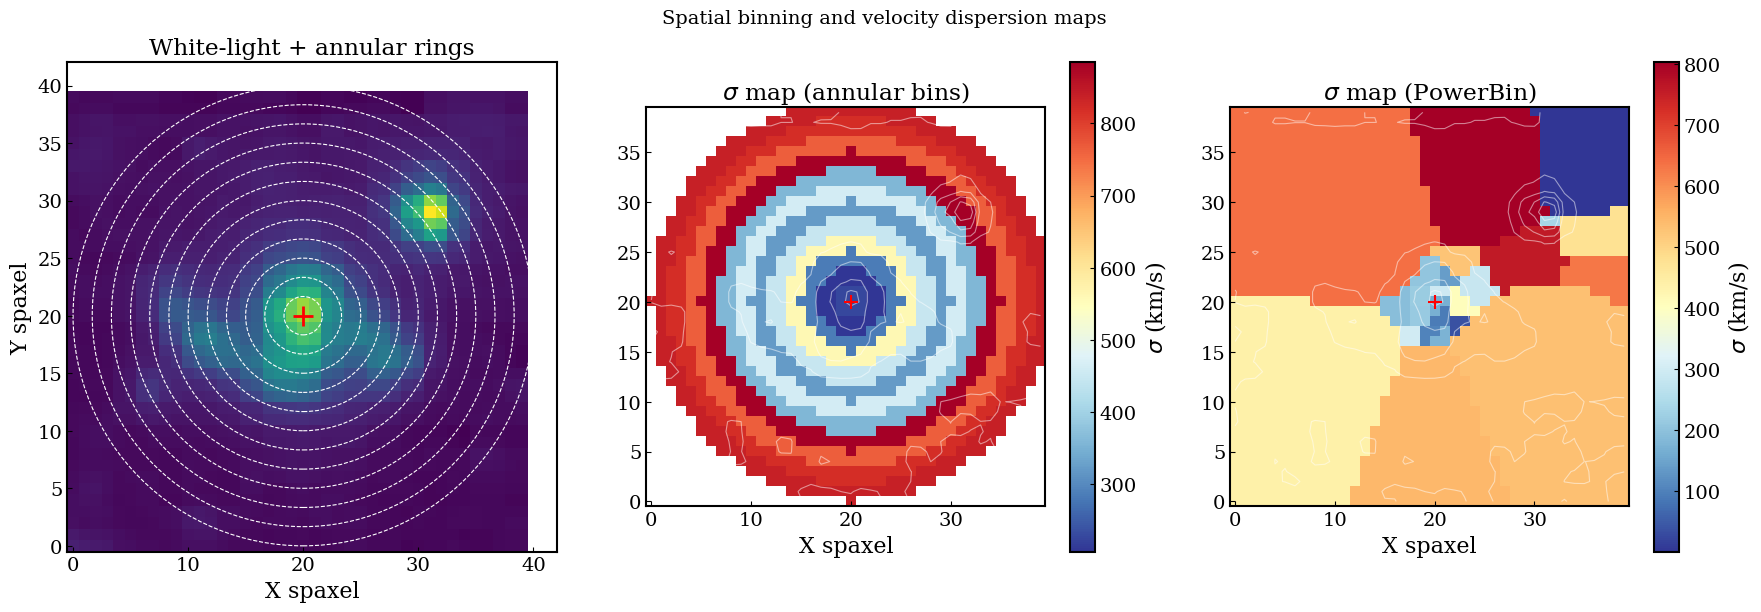

In [16]:
# Visualize the spatial bins on the IFU white-light image
from matplotlib.patches import Circle

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: White-light with annular rings (wide region)
ax = axes[0]
ax.imshow(whitelight_wide, origin="lower", cmap="viridis")
ax.plot(dx_peak, dy_peak, "r+", markersize=15, markeredgewidth=2)
# Overlay annular ring edges
for r_edge in r_edges:
    if r_edge > 0:
        r_pix = r_edge / spax_scale  # arcsec to spaxels
        circle = Circle((dx_peak, dy_peak), r_pix, fill=False, edgecolor="white", lw=0.8, ls="--")
        ax.add_patch(circle)
ax.set_title("White-light + annular rings")
ax.set_xlabel("X spaxel")
ax.set_ylabel("Y spaxel")

# Panel 2: Annular sigma map (wide region)
ax = axes[1]
sigma_map_ann = np.full(whitelight_wide.shape, np.nan)
for i in range(len(annular_r_mid)):
    r_lo = r_edges[i]
    r_hi = r_edges[i+1] if i+1 < len(r_edges) else r_edges[i] + 0.5
    bin_mask = (r_arcsec_spax >= r_lo) & (r_arcsec_spax < r_hi)
    sigma_map_ann[bin_mask] = sigma_annular[i]
im = ax.imshow(sigma_map_ann, origin="lower", cmap="RdYlBu_r")
ax.contour(whitelight_wide, levels=5, colors="white", alpha=0.5, linewidths=0.8)
ax.plot(dx_peak, dy_peak, "r+", markersize=10, markeredgewidth=1.5)
ax.set_title(r"$\sigma$ map (annular bins)")
ax.set_xlabel("X spaxel")
plt.colorbar(im, ax=ax, label=r"$\sigma$ (km/s)")

# Panel 3: PowerBin sigma map (wide region)
ax = axes[2]
sigma_pb_map = np.full(whitelight_wide.shape, np.nan)
for b_idx in range(n_bins_pb):
    sigma_pb_map[powerbin_idx_map == b_idx] = sigma_pb[b_idx]
im = ax.imshow(sigma_pb_map, origin="lower", cmap="RdYlBu_r")
ax.contour(whitelight_wide, levels=5, colors="white", alpha=0.5, linewidths=0.8)
ax.plot(dx_peak, dy_peak, "r+", markersize=10, markeredgewidth=1.5)
ax.set_title(r"$\sigma$ map (PowerBin)")
ax.set_xlabel("X spaxel")
plt.colorbar(im, ax=ax, label=r"$\sigma$ (km/s)")

plt.suptitle("Spatial binning and velocity dispersion maps", fontsize=14)
plt.tight_layout()
plt.show()


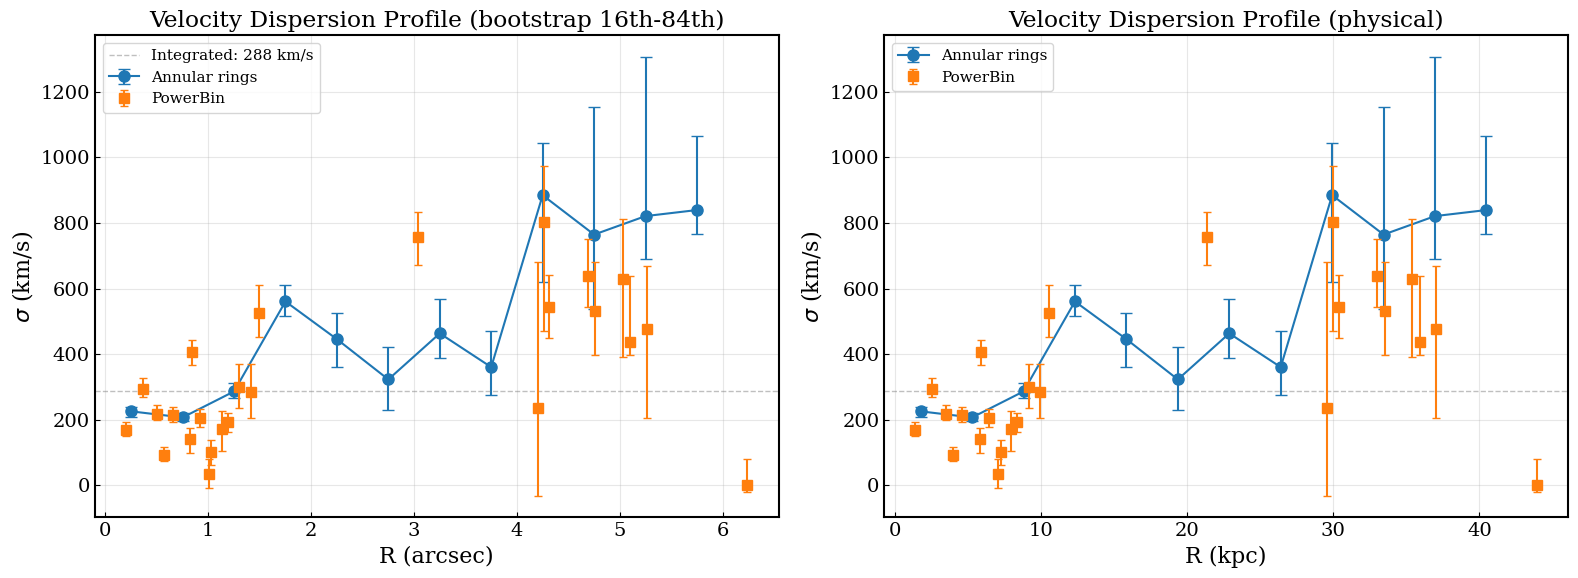

In [17]:
# Sigma(R) with bootstrap errors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: arcsec
ax = axes[0]
ax.errorbar(annular_r_mid, sigma_annular,
            yerr=[sigma_boot_lo_ann, sigma_boot_hi_ann],
            fmt="o-", color="C0", capsize=4, markersize=8, label="Annular rings")
ax.errorbar(pb_r_mean, sigma_pb,
            yerr=[sigma_boot_lo_pb, sigma_boot_hi_pb],
            fmt="s", color="C1", capsize=3, markersize=7, label="PowerBin", zorder=5)

try:
    boot_int = np.load("../results/ppxf_bootstrap_errors_fsps.npz", allow_pickle=True)
    sigma_int = np.median(boot_int["sigma_original"])
    ax.axhline(sigma_int, color="gray", ls="--", lw=1, alpha=0.5,
              label=f"Integrated: {sigma_int:.0f} km/s")
except FileNotFoundError:
    pass

ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title("Velocity Dispersion Profile (bootstrap 16th-84th)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Right: kpc
ax = axes[1]
ax.errorbar(annular_r_mid * kpc_per_arcsec, sigma_annular,
            yerr=[sigma_boot_lo_ann, sigma_boot_hi_ann],
            fmt="o-", color="C0", capsize=4, markersize=8, label="Annular rings")
ax.errorbar(pb_r_mean * kpc_per_arcsec, sigma_pb,
            yerr=[sigma_boot_lo_pb, sigma_boot_hi_pb],
            fmt="s", color="C1", capsize=3, markersize=7, label="PowerBin", zorder=5)
try:
    ax.axhline(sigma_int, color="gray", ls="--", lw=1, alpha=0.5)
except NameError:
    pass

ax.set_xlabel("R (kpc)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title("Velocity Dispersion Profile (physical)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/sigma_radial_profile.png", dpi=300, bbox_inches="tight")
plt.show()


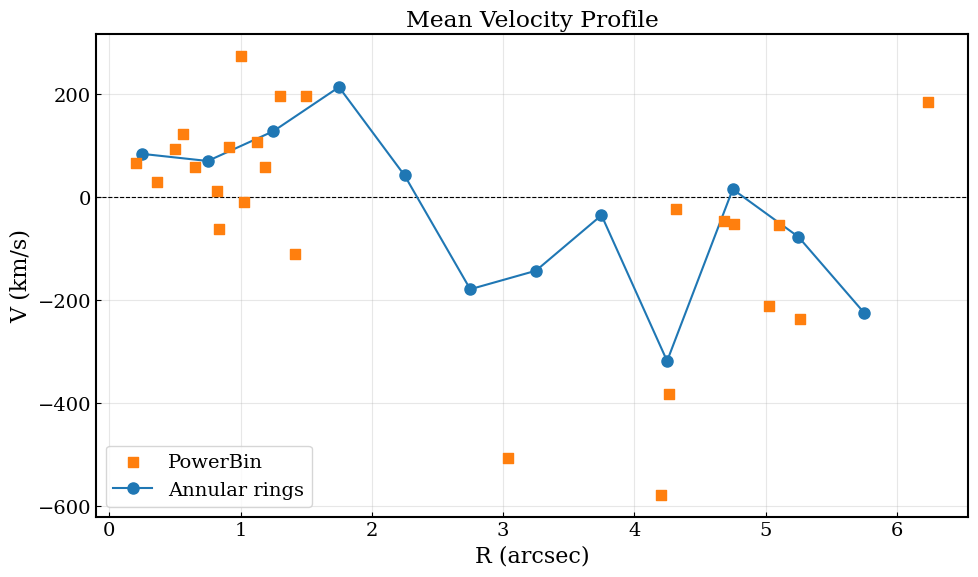

In [18]:
# Mean velocity profile (rotation curve)
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(annular_r_mid, V_annular, fmt='o-', color='C0', capsize=4,
            markersize=8, label='Annular rings')
ax.scatter(pb_r_mean, V_pb, c='C1', s=60, marker='s', zorder=5, label='PowerBin')
ax.axhline(0, color='k', ls='--', lw=0.8)

ax.set_xlabel('R (arcsec)')
ax.set_ylabel('V (km/s)')
ax.set_title('Mean Velocity Profile')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary and comparison

In [19]:
print('=' * 60)
print('RADIAL VELOCITY DISPERSION PROFILE — AGEL0206')
print('=' * 60)
print(f'\nDeflector center: RA={ra_center:.6f}, Dec={dec_center:.6f}')
print(f'Scale: {kpc_per_arcsec:.2f} kpc/arcsec at z={z_defl}')
print(f'\nAnnular bins: {len(annular_spectra)} rings')
print(f'PowerBin: {n_bins_pb} bins (target S/N={target_sn})')

print(f'\nAnnular sigma(R):')
print(f'{"R (arcsec)":>10} {"R (kpc)":>8} {"sigma":>7} {"err":>5} {"N_spax":>7}')
for r, s, e, n in zip(annular_r_mid, sigma_annular, sigma_err_annular, annular_n_spax):
    print(f'{r:10.2f} {r*kpc_per_arcsec:8.1f} {s:7.0f} {e:5.0f} {n:7d}')

# Save results
np.savez('../results/radial_sigma_profile.npz',
         annular_r_mid=annular_r_mid,
         annular_r_kpc=annular_r_mid * kpc_per_arcsec,
         sigma_annular=sigma_annular,
         sigma_err_annular=sigma_err_annular,
         V_annular=V_annular,
         annular_n_spax=annular_n_spax,
         pb_r_mean=pb_r_mean,
         sigma_pb=sigma_pb,
         sigma_err_pb=sigma_err_pb,
         V_pb=V_pb,
         ra_center=ra_center,
         dec_center=dec_center,
         kpc_per_arcsec=kpc_per_arcsec,
         z_defl=z_defl)
print('\nSaved: ../results/radial_sigma_profile.npz')

RADIAL VELOCITY DISPERSION PROFILE — AGEL0206

Deflector center: RA=31.556137, Dec=-1.238127
Scale: 7.04 kpc/arcsec at z=0.675

Annular bins: 12 rings
PowerBin: 25 bins (target S/N=10)

Annular sigma(R):
R (arcsec)  R (kpc)   sigma   err  N_spax
      0.25      1.8     226     8       9
      0.75      5.3     207     9      28
      1.25      8.8     286    12      40
      1.75     12.3     561    20      60
      2.25     15.8     446    14      84
      2.75     19.4     323    23      92
      3.25     22.9     463    19     116
      3.75     26.4     360    64     124
      4.25     29.9     885   172     152
      4.75     33.4     765   257     172
      5.25     37.0     821   172     172
      5.75     40.5     839    76     202

Saved: ../results/radial_sigma_profile.npz


In [20]:
# --- Method 2: R_e from HST F140W image (higher resolution) ---
from photutils.aperture import CircularAnnulus, ApertureStats, CircularAperture

hst_file = "../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits"
hst_mask_file = "../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits"

try:
    with fits.open(hst_file) as hdul:
        img_hst = hdul[0].data
        hdr_hst = hdul[0].header
        wcs_hst = WCS(hdr_hst)
    
    # Find center in HST pixel coords from our RA/Dec
    x_hst, y_hst = wcs_hst.world_to_pixel_values(ra_center, dec_center)
    x_hst, y_hst = float(x_hst), float(y_hst)
    print(f"HST center pixel: ({x_hst:.1f}, {y_hst:.1f})")
    
    # HST pixel scale
    hst_pixscale = 0.08  # arcsec/pix for WFC3/IR
    
    # Try to load mask
    try:
        mask_hst = fits.getdata(hst_mask_file).astype(bool)
        hst_has_mask = True
    except FileNotFoundError:
        mask_hst = None
        hst_has_mask = False
    img_hst_clean = np.nan_to_num(img_hst, nan=0.0)
    
    # Build radial profile from HST image
    r_hst_edges = np.arange(1, 80, 1)  # pixels (0.08-6.4 arcsec)
    r_hst_profile = []
    I_hst_profile = []
    
    for j in range(len(r_hst_edges) - 1):
        aper = CircularAnnulus((x_hst, y_hst), r_in=r_hst_edges[j], r_out=r_hst_edges[j+1])
        stats = ApertureStats(img_hst_clean, aper, mask=mask_hst) if hst_has_mask else ApertureStats(img_hst_clean, aper)
        if np.isfinite(stats.mean) and stats.mean > 0:
            r_hst_profile.append((r_hst_edges[j] + r_hst_edges[j+1]) / 2 * hst_pixscale)
            I_hst_profile.append(stats.mean)
    
    r_hst = np.array(r_hst_profile)
    I_hst = np.array(I_hst_profile)
    
    Re_hst, cog_hst, total_hst = measure_Re_from_profile(r_hst, I_hst)
    print(f"HST F140W R_e = {Re_hst:.2f} arcsec = {Re_hst * kpc_per_arcsec:.1f} kpc")
    print(f"R_e/8 = {Re_hst/8:.3f} arcsec = {Re_hst/8 * kpc_per_arcsec:.2f} kpc")
    
    hst_loaded = True
except FileNotFoundError:
    print("HST F140W file not found — skipping HST R_e")
    hst_loaded = False


HST center pixel: (157.5, 156.2)
HST F140W R_e = 2.60 arcsec = 18.3 kpc
R_e/8 = 0.324 arcsec = 2.28 kpc


In [ ]:
# --- Method 3: R_e from HST F200LP image ---
hst_f200_file = "../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3.fits"
hst_f200_mask_file = "../../velocity_dispersion_from_IFU/AGEL020613-011417A_F200LP_WFC3_cutout_L3_mask.fits"

try:
    with fits.open(hst_f200_file) as hdul:
        img_f200 = hdul[0].data
        hdr_f200 = hdul[0].header
        wcs_f200 = WCS(hdr_f200)

    x_f200, y_f200 = wcs_f200.world_to_pixel_values(ra_center, dec_center)
    x_f200, y_f200 = float(x_f200), float(y_f200)
    print(f"HST F200LP center pixel: ({x_f200:.1f}, {y_f200:.1f})")

    hst_pixscale_f200 = 0.08  # arcsec/pix for WFC3/UVIS

    try:
        mask_f200 = fits.getdata(hst_f200_mask_file).astype(bool)
        f200_has_mask = True
    except FileNotFoundError:
        mask_f200 = None
        f200_has_mask = False
    img_f200_clean = np.nan_to_num(img_f200, nan=0.0)

    # Build radial profile
    r_f200_edges = np.arange(1, 80, 1)
    r_f200_profile = []
    I_f200_profile = []

    for j in range(len(r_f200_edges) - 1):
        aper = CircularAnnulus((x_f200, y_f200), r_in=r_f200_edges[j], r_out=r_f200_edges[j+1])
        stats = ApertureStats(img_f200_clean, aper, mask=mask_f200) if f200_has_mask else ApertureStats(img_f200_clean, aper)
        if np.isfinite(stats.mean) and stats.mean > 0:
            r_f200_profile.append((r_f200_edges[j] + r_f200_edges[j+1]) / 2 * hst_pixscale_f200)
            I_f200_profile.append(stats.mean)

    r_f200 = np.array(r_f200_profile)
    I_f200 = np.array(I_f200_profile)

    Re_f200, cog_f200, total_f200 = measure_Re_from_profile(r_f200, I_f200)
    print(f"HST F200LP R_e = {Re_f200:.2f} arcsec = {Re_f200 * kpc_per_arcsec:.1f} kpc")
    print(f"R_e/8 = {Re_f200/8:.3f} arcsec = {Re_f200/8 * kpc_per_arcsec:.2f} kpc")
    f200_loaded = True
except FileNotFoundError:
    print("HST F200LP file not found — skipping")
    f200_loaded = False


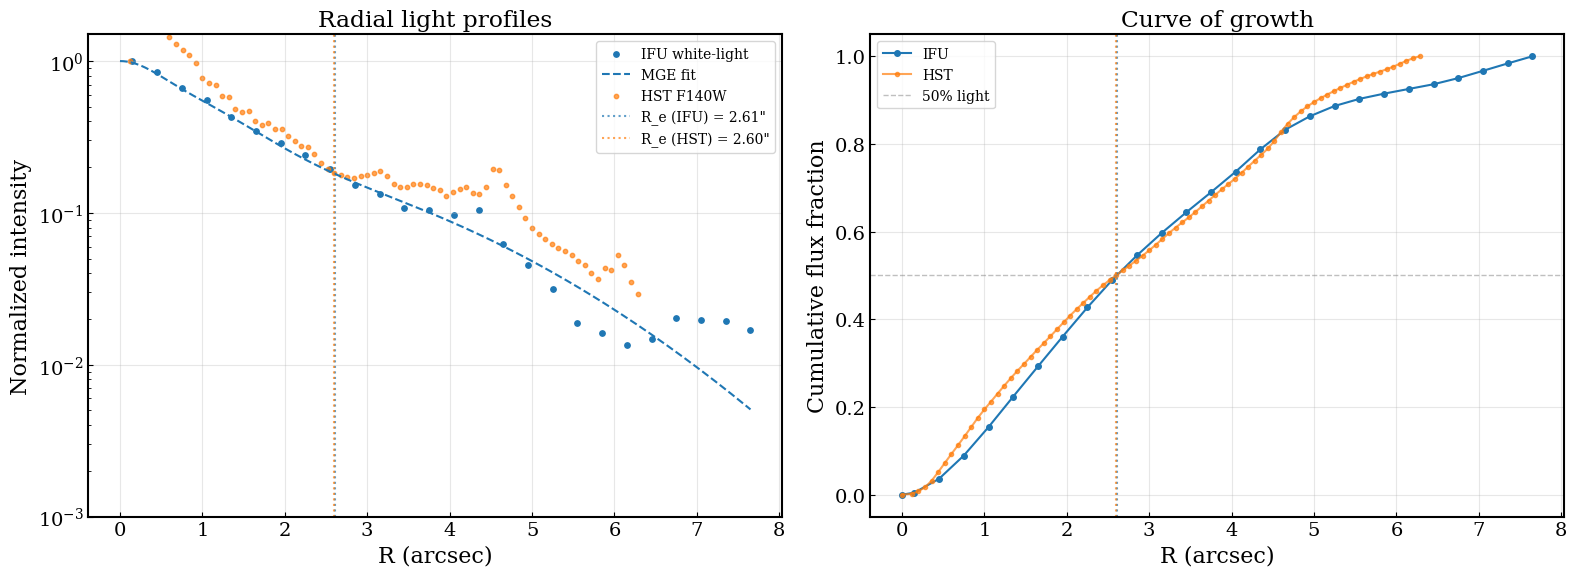

-----Effective radius summary ---
  IFU white-light: R_e = 2.61 arcsec = 18.3 kpc
  MGE model:       R_e = 2.58 arcsec = 18.2 kpc
  HST F140W:       R_e = 2.60 arcsec = 18.3 kpc
--- Sigma at standard apertures ---
  R_e = 2.60 arcsec
  R_e/8 = 0.324 arcsec = 2.28 kpc
  sigma(R<R_e/8 ~ 0.3) = 212 km/s
  sigma(R<R_e ~ 2.6) = 316 km/s


In [21]:
# Plot curves of growth and R_e comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: radial profiles
ax = axes[0]
ax.scatter(r_fit, I_fit / I_fit[0], c="C0", s=15, label="IFU white-light")
if popt is not None:
    r_dense = np.linspace(0, max(r_fit.max(), 5), 200)
    ax.plot(r_dense, multi_gaussian_1d(r_dense, *popt) / multi_gaussian_1d(np.array([0]), *popt),
            "C0--", lw=1.5, label="MGE fit")
if hst_loaded:
    ax.scatter(r_hst, I_hst / I_hst[0], c="C1", s=10, alpha=0.7, label="HST F140W")
if f200_loaded:
    ax.scatter(r_f200, I_f200 / I_f200[0], c="C2", s=10, alpha=0.7, label="HST F200LP")
ax.set_xlabel("R (arcsec)")
ax.set_ylabel("Normalized intensity")
ax.set_title("Radial light profiles")
ax.set_yscale("log")
ax.set_ylim(1e-3, 1.5)
ax.axvline(Re_ifu, color="C0", ls=":", lw=1.5, alpha=0.7, label=f"R_e (IFU) = {Re_ifu:.2f}\"")
if hst_loaded:
    ax.axvline(Re_hst, color="C1", ls=":", lw=1.5, alpha=0.7, label=f"R_e (HST) = {Re_hst:.2f}\"")
if f200_loaded:
    ax.axvline(Re_f200, color="C2", ls=":", lw=1.5, alpha=0.7, label=f"R_e (F200LP) = {Re_f200:.2f}\"")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: curves of growth
ax = axes[1]
# cog has len = len(r_fit)+1 because measure_Re prepends r=0
r_cog_ifu = np.concatenate([[0], r_fit])  # match the prepended r=0
ax.plot(r_cog_ifu, cog_ifu / total_ifu, "C0-o", markersize=4, label="IFU")
if hst_loaded:
    r_cog_hst = np.concatenate([[0], r_hst])
ax.plot(r_cog_hst, cog_hst / total_hst, "C1-o", markersize=3, alpha=0.7, label="HST")
if f200_loaded:
    r_cog_f200 = np.concatenate([[0], r_f200])
    ax.plot(r_cog_f200, cog_f200 / total_f200, "C2-o", markersize=3, alpha=0.7, label="HST F200LP")
ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.5, label="50% light")
ax.axvline(Re_ifu, color="C0", ls=":", lw=1.5, alpha=0.7)
if hst_loaded:
    ax.axvline(Re_hst, color="C1", ls=":", lw=1.5, alpha=0.7)
ax.set_xlabel("R (arcsec)")
ax.set_ylabel("Cumulative flux fraction")
ax.set_title("Curve of growth")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f"-----Effective radius summary ---")
print(f"  IFU white-light: R_e = {Re_ifu:.2f} arcsec = {Re_ifu*kpc_per_arcsec:.1f} kpc")
if popt is not None:
    print(f"  MGE model:       R_e = {Re_mge:.2f} arcsec = {Re_mge*kpc_per_arcsec:.1f} kpc")
if hst_loaded:
    print(f"  HST F140W:       R_e = {Re_hst:.2f} arcsec = {Re_hst*kpc_per_arcsec:.1f} kpc")
if f200_loaded:
    print(f"  HST F200LP:      R_e = {Re_f200:.2f} arcsec = {Re_f200*kpc_per_arcsec:.1f} kpc")
print(f"--- Sigma at standard apertures ---")
Re_best = Re_hst if hst_loaded else Re_ifu
print(f"  R_e = {Re_best:.2f} arcsec")
print(f"  R_e/8 = {Re_best/8:.3f} arcsec = {Re_best/8*kpc_per_arcsec:.2f} kpc")
# Find the integrated sigma closest to Re/8
if len(aperture_results) > 0:
    r_ap_arr = np.array([r["r_max"] for r in aperture_results])
    sigma_ap = np.array([r["sigma"] for r in aperture_results])
    idx_re8 = np.argmin(np.abs(r_ap_arr - Re_best/8))
    idx_re = np.argmin(np.abs(r_ap_arr - Re_best))
    print(f"  sigma(R<R_e/8 ~ {r_ap_arr[idx_re8]:.1f}) = {sigma_ap[idx_re8]:.0f} km/s")
    print(f"  sigma(R<R_e ~ {r_ap_arr[idx_re]:.1f}) = {sigma_ap[idx_re]:.0f} km/s")


## 10. Combined posterior: final sigma and V

Pool ALL bootstrap samples across 3 templates, degrees 15-29.
The 16th/84th percentiles give the final 1-sigma error bars,
matching the approach used in the final Figure 2.

In [22]:
# Pool bootstrap across all templates for R < R_e
Nboot = 100
combined_sigma = []
combined_V = []

mask_Re = r_arcsec_spax <= Re_best
spec_Re = np.average(cube_wide[:, mask_Re], axis=1)
n_spax_Re = np.sum(mask_Re)
print(f'R_e = {Re_best:.2f} arcsec, {n_spax_Re} spaxels within aperture')

for sps_name in ['fsps', 'emiles', 'xsl']:
    print(f'  Bootstrap {sps_name}...')
    b = bootstrap_radial_bin(spec_Re, noise_sky, n_bootstrap=Nboot,
                              degrees=np.arange(15, 30), sps_name=sps_name,
                              seed=42, verbose=False)
    combined_sigma.extend(b['sigma_samples'].tolist())
    combined_V.extend(b['V_samples'].tolist())

combined_sigma = np.array(combined_sigma)
combined_sigma = combined_sigma[np.isfinite(combined_sigma)]
combined_V = np.array(combined_V)
combined_V = combined_V[np.isfinite(combined_V)]

sig_p16, sig_p50, sig_p84 = np.percentile(combined_sigma, [16, 50, 84])
V_p16, V_p50, V_p84 = np.percentile(combined_V, [16, 50, 84])

sep = '=' * 60
print(f'\n{sep}')
print('COMBINED POSTERIOR (R < R_e, 3 templates, deg 15-29, N=200 each)')
print(sep)
print(f'  sigma = {sig_p50:.0f} -{sig_p50-sig_p16:.0f}/+{sig_p84-sig_p50:.0f} km/s')
print(f'  V     = {V_p50:.0f} -{V_p50-V_p16:.0f}/+{V_p84-V_p50:.0f} km/s')
print(f'  N samples: {len(combined_sigma)} (sigma), {len(combined_V)} (V)')
print(sep)

# Also R < R_e/8
print('\nRunning combined bootstrap for R < R_e/8...')
combined_sigma_re8 = []
combined_V_re8 = []
mask_Re8 = r_arcsec_spax <= Re_best/8
n_spax_Re8 = np.sum(mask_Re8)
if n_spax_Re8 >= 2:
    spec_Re8 = np.average(cube_wide[:, mask_Re8], axis=1)
    print(f'  {n_spax_Re8} spaxels within R_e/8 = {Re_best/8:.3f} arcsec')
    for sps_name in ['fsps', 'emiles', 'xsl']:
        b = bootstrap_radial_bin(spec_Re8, noise_sky, n_bootstrap=Nboot,
                                  degrees=np.arange(15, 30), sps_name=sps_name,
                                  seed=42, verbose=False)
        combined_sigma_re8.extend(b['sigma_samples'].tolist())
        combined_V_re8.extend(b['V_samples'].tolist())
    combined_sigma_re8 = np.array(combined_sigma_re8)
    combined_sigma_re8 = combined_sigma_re8[np.isfinite(combined_sigma_re8)]
    combined_V_re8 = np.array(combined_V_re8)
    combined_V_re8 = combined_V_re8[np.isfinite(combined_V_re8)]
    s8_p16, s8_p50, s8_p84 = np.percentile(combined_sigma_re8, [16, 50, 84])
    V8_p16, V8_p50, V8_p84 = np.percentile(combined_V_re8, [16, 50, 84])
    print(f'  sigma(R<Re/8) = {s8_p50:.0f} -{s8_p50-s8_p16:.0f}/+{s8_p84-s8_p50:.0f} km/s')
    print(f'  V(R<Re/8)     = {V8_p50:.0f} -{V8_p50-V8_p16:.0f}/+{V8_p84-V8_p50:.0f} km/s')
else:
    print(f'  Only {n_spax_Re8} spaxels within R_e/8 -- too few')


R_e = 2.60 arcsec, 241 spaxels within aperture
  Bootstrap fsps...
 Best Fit:       Vel     sigma
 comp.  0:       -25       215
chi2/DOF: 0.04527; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387
 Best Fit:       Vel     sigma
 comp.  0:       -10       244
chi2/DOF: 0.05503; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -23       187
chi2/DOF: 0.05418; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -51       230
chi2/DOF: 0.05485; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/387
 Best F

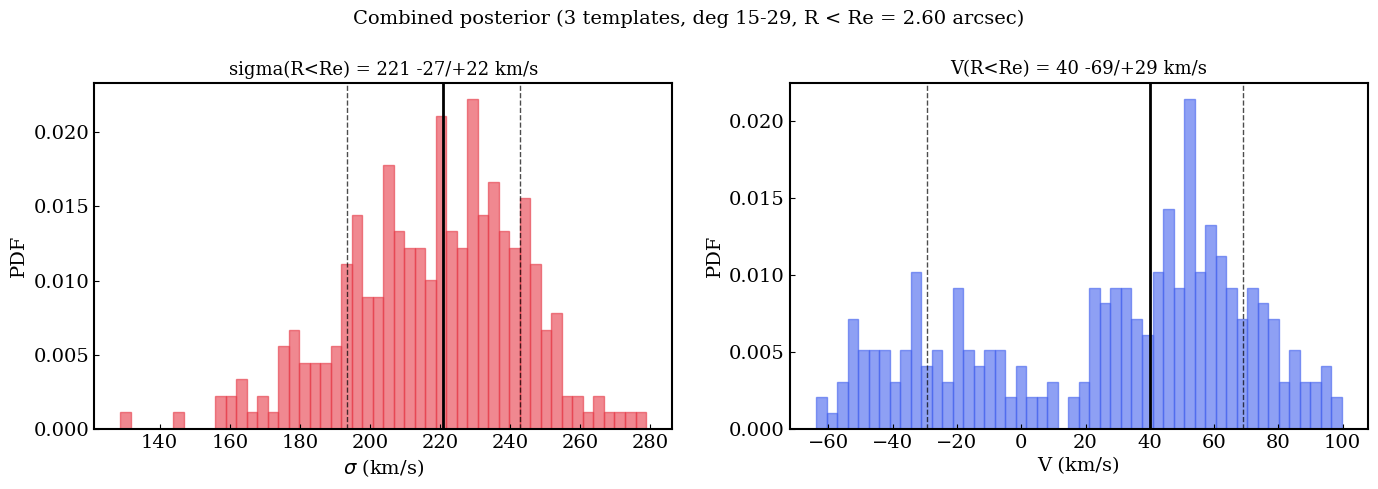

Saved: ../results/radial_sigma_combined_posterior.npz


In [23]:
# Plot combined posteriors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(combined_sigma, bins=50, color='#e63946', alpha=0.6, edgecolor='#e63946', density=True)
ax.axvline(sig_p50, color='k', ls='-', lw=2)
ax.axvline(sig_p16, color='k', ls='--', lw=1, alpha=0.7)
ax.axvline(sig_p84, color='k', ls='--', lw=1, alpha=0.7)
ax.set_xlabel(r'$\sigma$ (km/s)', fontsize=14)
ax.set_ylabel('PDF', fontsize=14)
sig_title = f'sigma(R<Re) = {sig_p50:.0f} -{sig_p50-sig_p16:.0f}/+{sig_p84-sig_p50:.0f} km/s'
ax.set_title(sig_title, fontsize=13)

ax = axes[1]
ax.hist(combined_V, bins=50, color='#4361ee', alpha=0.6, edgecolor='#4361ee', density=True)
ax.axvline(V_p50, color='k', ls='-', lw=2)
ax.axvline(V_p16, color='k', ls='--', lw=1, alpha=0.7)
ax.axvline(V_p84, color='k', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('V (km/s)', fontsize=14)
ax.set_ylabel('PDF', fontsize=14)
V_title = f'V(R<Re) = {V_p50:.0f} -{V_p50-V_p16:.0f}/+{V_p84-V_p50:.0f} km/s'
ax.set_title(V_title, fontsize=13)

fig.suptitle(f'Combined posterior (3 templates, deg 15-29, R < Re = {Re_best:.2f} arcsec)', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/sigma_V_combined_posterior.png', dpi=300, bbox_inches='tight')
plt.show()

# Save
np.savez('../results/radial_sigma_combined_posterior.npz',
         combined_sigma=combined_sigma, combined_V=combined_V,
         sig_p16=sig_p16, sig_p50=sig_p50, sig_p84=sig_p84,
         V_p16=V_p16, V_p50=V_p50, V_p84=V_p84,
         Re_arcsec=Re_best, Re_kpc=Re_best*kpc_per_arcsec,
         n_spax_Re=n_spax_Re, z_defl=z_defl)
print('Saved: ../results/radial_sigma_combined_posterior.npz')
